

| Pathway | What it does | Implementation |
|---------|--------------|----------------|
| **X** | Local contrast (center-surround) | `3×3 Conv` - `1×1 Conv` |
| **Y** | Large RF contrast | `5×5 Dilated Conv` - `1×1 Conv` |
| **W** | Directional | `1×3 Conv` (horizontal) + `3×1 Conv` (vertical) |

**W pathway is NOT Gabor filters** - it's separable directional convolutions.

**Gabor filters** are specifically oriented edge detectors with sinusoidal patterns at different angles (0°, 45°, 90°, 135°, etc.). They're biologically inspired by V1 cortex cells.



# Backup + S3 configuration (optional) 

In [2]:


from pathlib import Path
import time
import uuid

# -------------------------------
# Local mirror (optional)
# -------------------------------
# Set to a folder path (string or Path). Keep as None to disable.
BACKUP_DIR = "./backup"  # or None to disable
# Safe optional write test (creates a tiny file).
RUN_BACKUP_TEST = True

# -------------------------------
# S3 / S3-compatible mirror (optional)
# -------------------------------
# Keep S3_BUCKET=None to disable. Provide endpoint_url for MinIO/OSS/etc.
S3_BUCKET = None
S3_PREFIX = "xywnet"
S3_ENDPOINT_URL = None  # e.g. "http://127.0.0.1:9000" for MinIO
S3_REGION = None        # optional (often needed on AWS), e.g. "us-east-1"

# Optional explicit credentials (leave None to use boto3 default credential chain).
S3_ACCESS_KEY_ID = None
S3_SECRET_ACCESS_KEY = None

# Safe optional write test (uploads a tiny object).
RUN_S3_TEST = False

def _mask(s: str, keep: int = 4) -> str:
    if not s:
        return ""
    if len(s) <= keep:
        return "*" * len(s)
    return "*" * (len(s) - keep) + s[-keep:]

def show_backup_status() -> None:
    print("\nBackup status (no env vars)")
    print("- Local mirror:", str(BACKUP_DIR) if BACKUP_DIR else "DISABLED (set BACKUP_DIR)")
    print("- S3 bucket:", S3_BUCKET if S3_BUCKET else "DISABLED (set S3_BUCKET)")
    if S3_BUCKET:
        print("  - prefix:", S3_PREFIX or "(none)")
        print("  - endpoint:", S3_ENDPOINT_URL or "(aws)")
        print("  - region:", S3_REGION or "(auto)")
        print("  - access key:", _mask(S3_ACCESS_KEY_ID) if S3_ACCESS_KEY_ID else "(auto)")
        print("  - secret key:", _mask(S3_SECRET_ACCESS_KEY) if S3_SECRET_ACCESS_KEY else "(auto)")

show_backup_status()

S3_CLIENT = None
S3_ENABLED = False
if S3_BUCKET:
    try:
        import boto3
        client_kwargs = {}
        if S3_ENDPOINT_URL:
            client_kwargs["endpoint_url"] = S3_ENDPOINT_URL
        if S3_REGION:
            client_kwargs["region_name"] = S3_REGION
        if S3_ACCESS_KEY_ID and S3_SECRET_ACCESS_KEY:
            client_kwargs["aws_access_key_id"] = S3_ACCESS_KEY_ID
            client_kwargs["aws_secret_access_key"] = S3_SECRET_ACCESS_KEY
        S3_CLIENT = boto3.client("s3", **client_kwargs)
        S3_ENABLED = True
        # RUN_DIR is defined later; show a generic status for now.
        print("✓ S3 client ready")
    except Exception as e:
        S3_CLIENT = None
        S3_ENABLED = False
        print(f"! S3 disabled (boto3/config issue): {e}")

# Optional: local backup write test
if RUN_BACKUP_TEST:
    if not BACKUP_DIR:
        print("! RUN_BACKUP_TEST=True but BACKUP_DIR is None")
    else:
        p = Path(BACKUP_DIR) / "_xyw_backup_test"
        p.mkdir(parents=True, exist_ok=True)
        test_file = p / "hello.txt"
        test_file.write_text(f"ok {time.time()}\n", encoding="utf-8")
        print(f"✓ Local backup test wrote: {test_file}")

# Optional: S3 write test
if RUN_S3_TEST:
    if not S3_BUCKET or S3_CLIENT is None:
        print("! RUN_S3_TEST=True but S3 is not configured")
    else:
        try:
            key = "/".join([x for x in [S3_PREFIX.strip("/"), "_xyw_s3_test", f"{uuid.uuid4().hex}.txt"] if x])
            S3_CLIENT.put_object(Bucket=S3_BUCKET, Key=key, Body=b"ok")
            print(f"✓ S3 test uploaded: s3://{S3_BUCKET}/{key}")
        except Exception as e:
            print(f"! S3 test failed: {e}")


Backup status (no env vars)
- Local mirror: ./backup
- S3 bucket: DISABLED (set S3_BUCKET)
✓ Local backup test wrote: backup\_xyw_backup_test\hello.txt


In [3]:
# Cell 1: Imports and Setup
import torch
import torch.nn as nn
import torch.nn.functional as F
import torch.optim as optim
from torch.utils.data import Dataset, DataLoader
import numpy as np
import cv2
from pathlib import Path
import matplotlib.pyplot as plt
from tqdm import tqdm
import math
import pandas as pd
from sklearn.metrics import precision_recall_curve, average_precision_score
import os
import torch.nn.functional as F
import json
from datetime import datetime

# Device setup
device = torch.device('cuda' if torch.cuda.is_available() else 'cpu')
print(f"Using device: {device}")
if torch.cuda.is_available():
    print(f"GPU: {torch.cuda.get_device_name(0)}")
    print(f"Memory: {torch.cuda.get_device_properties(0).total_memory / 1e9:.1f} GB")

# ============================================================
# Organized run output folders
# ============================================================
RUNS_DIR = Path("runs")
RUNS_DIR.mkdir(exist_ok=True)
RUN_ID = datetime.now().strftime("xywnet_%Y%m%d_%H%M%S")
RUN_DIR = RUNS_DIR / RUN_ID
RUN_DIR.mkdir(parents=True, exist_ok=True)

CHECKPOINT_DIR = RUN_DIR / "checkpoints"
ARTIFACTS_DIR = RUN_DIR / "artifacts"
PREDICTIONS_DIR = RUN_DIR / "predictions"
for d in [CHECKPOINT_DIR, ARTIFACTS_DIR, PREDICTIONS_DIR]:
    d.mkdir(parents=True, exist_ok=True)

# Optional legacy folder (kept for compatibility with older cells / resume paths)
Path("models").mkdir(exist_ok=True)

# Prediction export controls
EXPORT_TEST_PREDICTIONS = True
PRED_EXPORT_MAX_IMAGES = 100  # set larger if you want to export more
print(f"\nRun dir: {RUN_DIR}")

Using device: cuda
GPU: NVIDIA GeForce GTX 1070
Memory: 8.6 GB

Run dir: runs\xywnet_20251225_212001


In [4]:
import torch

print("CUDA available:", torch.cuda.is_available())
print("GPU name:", torch.cuda.get_device_name(0))
print("Total VRAM (GB):", round(torch.cuda.get_device_properties(0).total_memory / 1024**3, 2))


CUDA available: True
GPU name: NVIDIA GeForce GTX 1070
Total VRAM (GB): 8.0


In [5]:
from pathlib import Path
from torch.utils.data import Dataset, DataLoader
import cv2
import torch
import numpy as np
import os

# Cell 2: Environment-aware Dataset Loader
class ProcessedDataset(Dataset):
    """Load processed PNG images and edge maps with ImageNet normalization"""

    def __init__(self, root_dir, split='train'):
        self.root_dir = Path(root_dir)
        self.split = split
        self.img_dir = self.root_dir / split / 'images'
        self.edge_dir = self.root_dir / split / 'edges'
        
        # Verify paths exist
        if not self.img_dir.exists():
            raise FileNotFoundError(f"Image directory not found: {self.img_dir}")
        if not self.edge_dir.exists():
            raise FileNotFoundError(f"Edge directory not found: {self.edge_dir}")
        
        self.samples = sorted(list(self.img_dir.glob('*.png')))
        if len(self.samples) == 0:
            raise ValueError(f"No PNG files found in {self.img_dir}")
        
        # ImageNet normalization (standard for edge detection models)
        self.mean = torch.tensor([0.485, 0.456, 0.406]).view(3, 1, 1)
        self.std = torch.tensor([0.229, 0.224, 0.225]).view(3, 1, 1)

    def __len__(self):
        return len(self.samples)

    def __getitem__(self, idx):
        img_path = self.samples[idx]
        edge_path = self.edge_dir / img_path.name

        # Load image
        img = cv2.imread(str(img_path))
        if img is None:
            raise IOError(f"Failed to load image: {img_path}")
        img = cv2.cvtColor(img, cv2.COLOR_BGR2RGB)
        img = img.astype(np.float32) / 255.0

        # Load edge map
        edge = cv2.imread(str(edge_path), cv2.IMREAD_GRAYSCALE)
        if edge is None:
            raise IOError(f"Failed to load edge map: {edge_path}")
        edge = edge.astype(np.float32) / 255.0

        # To tensors
        img = torch.from_numpy(img).permute(2, 0, 1)
        # Apply ImageNet normalization
        img = (img - self.mean) / self.std
        edge = torch.from_numpy(edge).unsqueeze(0)

        return {'images': img, 'labels': edge, 'filename': img_path.stem}
def _pad_to(img_chw: torch.Tensor, target_h: int, target_w: int, *, value: float = 0.0) -> torch.Tensor:
    _, h, w = img_chw.shape
    pad_h = int(target_h - h)
    pad_w = int(target_w - w)
    if pad_h < 0 or pad_w < 0:
        raise ValueError(f'Target smaller than input: ({h},{w}) -> ({target_h},{target_w})')
    if pad_h == 0 and pad_w == 0:
        return img_chw
    return F.pad(img_chw, (0, pad_w, 0, pad_h), value=float(value))
def pad_collate(batch, *, pad_to_multiple: int = 32):
    # Batch is a list of dicts with CHW images and 1HW labels
    images = [b['images'] for b in batch]
    labels = [b['labels'] for b in batch]
    filenames = [b.get('filename', 'unknown') for b in batch]

    max_h = max(int(x.shape[1]) for x in images)
    max_w = max(int(x.shape[2]) for x in images)
    if pad_to_multiple and pad_to_multiple > 1:
        m = int(pad_to_multiple)
        max_h = ((max_h + m - 1) // m) * m
        max_w = ((max_w + m - 1) // m) * m

    images_p = [_pad_to(x, max_h, max_w, value=0.0) for x in images]
    labels_p = [_pad_to(y, max_h, max_w, value=0.0) for y in labels]

    return {'images': torch.stack(images_p, dim=0), 'labels': torch.stack(labels_p, dim=0), 'filename': filenames}


# ============================================================
# Environment Detection: Local / Kaggle / HPC
# ============================================================
def detect_environment():
    """Auto-detect execution environment and choose dataset path + num_workers"""
    
    # Small portable dataset (recommended for multi-device/Kaggle uploads)
    small_local = "./datasets/RCF_small/processed_HED_BSDS_small"
    small_kaggle_candidates = [
        "/kaggle/input/processed-hed-bsds-small/processed_HED_BSDS_small",
        "/kaggle/input/hed-bsds-small/processed_HED_BSDS_small",
        "/kaggle/input/rcf-small/processed_HED_BSDS_small",
    ]
    
    # 1. Check if Kaggle
    if os.path.exists("/kaggle/input"):
        env = "kaggle"
        # Prefer the small dataset if present; otherwise fall back to your older Kaggle dataset.
        paths = [
            *small_kaggle_candidates,
            "/kaggle/input/hed-bsds-v2/processed_HED_v2",
            "/kaggle/input/hed-bsds-v2/HED_Small",
        ]
        num_workers = 2  # Kaggle allows multi-process I/O
    
    # 2. Check if HPC (Slurm environment variables)
    elif "SLURM_JOB_ID" in os.environ or "PBS_JOBID" in os.environ:
        env = "hpc"
        paths = [
            small_local,
            "./datasets/HED_Small",
            "/scratch/datasets/HED_Small",
            "/data/HED_Small",
        ]
        num_workers = min(4, os.cpu_count() - 1) if os.cpu_count() else 2
    
# 3. Default: Local
    else:
        env = "local"
        # Prefer the small portable dataset if present.
        paths = [
            small_local,
            "./datasets/HED_Medium",
        ]
        num_workers = 0  # Windows/Mac often have issues with multiprocessing
    
# Find first existing path
    data_root = None
    for p in paths:
        if os.path.exists(p):
            data_root = p
            break
    
    if data_root is None:
        print(f"⚠ WARNING: No dataset found in {env.upper()} environment.")
        print(f"Tried paths: {paths}")
        print("Using default path (may fail if dataset not available):")
        data_root = paths[0]
    
    return env, data_root, num_workers

# Auto-detect
environment, DATA_ROOT, NUM_WORKERS = detect_environment()
print(f"Environment: {environment.upper()}")
print(f"Dataset root: {DATA_ROOT}")
print(f"num_workers: {NUM_WORKERS}")
print("=" * 60)

# ============================================================
# Load Datasets
# ============================================================
BATCH_SIZE = 4

try:
    train_dataset = ProcessedDataset(DATA_ROOT, split='train')
    val_dataset   = ProcessedDataset(DATA_ROOT, split='val') if os.path.exists(f"{DATA_ROOT}/val") else ProcessedDataset(DATA_ROOT, split='test')
    test_dataset  = ProcessedDataset(DATA_ROOT, split='test')
    
    _collate = lambda b: pad_collate(b, pad_to_multiple=32)
    train_loader = DataLoader(train_dataset, batch_size=BATCH_SIZE, shuffle=True,  num_workers=NUM_WORKERS, pin_memory=True, collate_fn=_collate)
    val_loader   = DataLoader(val_dataset,   batch_size=BATCH_SIZE, shuffle=False, num_workers=NUM_WORKERS, pin_memory=True, collate_fn=_collate)
    test_loader  = DataLoader(test_dataset,  batch_size=BATCH_SIZE, shuffle=False, num_workers=NUM_WORKERS, pin_memory=True, collate_fn=_collate)
    
    print(f"✓ Train: {len(train_dataset)} samples")
    print(f"✓ Val:   {len(val_dataset)} samples")
    print(f"✓ Test:  {len(test_dataset)} samples")
    
    # Verify sample
    sample = train_dataset[0]
    print(f"✓ Image shape: {sample['images'].shape}")
    print(f"✓ Edge shape:  {sample['labels'].shape}")
    print("=" * 60)
    
except Exception as e:
    print(f"✗ Dataset loading failed: {e}")
    print("Make sure the dataset path is correct and accessible.")

Environment: LOCAL
Dataset root: ./datasets/RCF_small/processed_HED_BSDS_small
num_workers: 0
✓ Train: 200 samples
✓ Val:   50 samples
✓ Test:  50 samples
✓ Image shape: torch.Size([3, 320, 226])
✓ Edge shape:  torch.Size([1, 320, 226])


In [6]:
import cv2
import os
import numpy as np
from pathlib import Path
from tqdm import tqdm

def verify_edges(root_dir, split="train"):
    """Verify dataset integrity for a given split"""
    root_dir = Path(root_dir)
    img_dir = root_dir / split / "images"
    edge_dir = root_dir / split / "edges"

    # Check if split directories exist
    if not img_dir.exists() or not edge_dir.exists():
        print(f"⚠ Split '{split}' not found in {root_dir}")
        return

    image_files = sorted(list(img_dir.glob("*.png")))
    if len(image_files) == 0:
        print(f"⚠ No PNG files in {img_dir}")
        return

    missing_edges = []
    unreadable_edges = []
    empty_edges = []
    size_mismatch = []

    print(f"\nVerifying split: {split}")
    print("=" * 60)

    for img_path in tqdm(image_files, desc=f"Checking {split}", unit="img"):
        edge_path = edge_dir / img_path.name

        # 1. Check if edge file exists
        if not edge_path.exists():
            missing_edges.append(img_path.name)
            continue

        # 2. Try loading edge
        edge = cv2.imread(str(edge_path), cv2.IMREAD_GRAYSCALE)
        if edge is None:
            unreadable_edges.append(img_path.name)
            continue

        # 3. Check if edge is empty (all zeros)
        if np.sum(edge) == 0:
            empty_edges.append(img_path.name)

        # 4. Check size match
        img = cv2.imread(str(img_path))
        if img is None or edge.shape != img.shape[:2]:
            size_mismatch.append(img_path.name)

    # ===== REPORT =====
    print(f"\nVerification Report for split: {split}")
    print("=" * 60)
    print(f"Total images checked: {len(image_files)}")
    print(f"Missing edge files: {len(missing_edges)}")
    print(f"Unreadable edge files: {len(unreadable_edges)}")
    print(f"Empty edge maps: {len(empty_edges)}")
    print(f"Size mismatches: {len(size_mismatch)}")

    if missing_edges:
        print("\nMissing edge files (first 10):")
        print(missing_edges[:10])

    if unreadable_edges:
        print("\nUnreadable edge files (first 10):")
        print(unreadable_edges[:10])

    if empty_edges:
        print("\nEmpty edge maps (first 10):")
        print(empty_edges[:10])

    if size_mismatch:
        print("\nSize mismatches (first 10):")
        print(size_mismatch[:10])

    if not (missing_edges or unreadable_edges or empty_edges or size_mismatch):
        print("\n✓ All images have valid, non-empty, correctly-sized edge maps.")

# =========================
# Verify all available splits
# =========================
print(f"Using dataset root: {DATA_ROOT}")
print("=" * 60)

for split in ["train", "val", "test"]:
    verify_edges(DATA_ROOT, split)

Using dataset root: ./datasets/RCF_small/processed_HED_BSDS_small

Verifying split: train


Checking train: 100%|██████████| 200/200 [00:00<00:00, 377.50img/s]



Verification Report for split: train
Total images checked: 200
Missing edge files: 0
Unreadable edge files: 0
Empty edge maps: 0
Size mismatches: 0

✓ All images have valid, non-empty, correctly-sized edge maps.

Verifying split: val


Checking val: 100%|██████████| 50/50 [00:00<00:00, 427.50img/s]



Verification Report for split: val
Total images checked: 50
Missing edge files: 0
Unreadable edge files: 0
Empty edge maps: 0
Size mismatches: 0

✓ All images have valid, non-empty, correctly-sized edge maps.

Verifying split: test


Checking test: 100%|██████████| 50/50 [00:00<00:00, 434.01img/s]


Verification Report for split: test
Total images checked: 50
Missing edge files: 0
Unreadable edge files: 0
Empty edge maps: 0
Size mismatches: 0

✓ All images have valid, non-empty, correctly-sized edge maps.


# XYW-Net model

In [7]:
# Cell: Original-aligned XYW-Net model (encoder + RCF-style decoder) with ELC toggle
import torch
import torch.nn as nn
import torch.nn.functional as F
import math
import numpy as np

# --- Decoder mode toggle ---
# Use 'rcf' for the baseline decoder (released code default), or 'elc' to enable the Edge Localization Convolution path.
DECODE_MODE = 'rcf'  # options: 'rcf' | 'elc'

# --- PDC (Pixel Difference Convolution) minimal subset ---
def createPDCFunc(PDC_type):
    assert PDC_type in ['cv', '2sd']
    if PDC_type == 'cv':
        return F.conv2d
    if PDC_type == '2sd':
        def func(x, weights, bias=None, stride=1, padding=0, dilation=1, groups=1):
            assert weights.size(2) == 3 and weights.size(3) == 3
            shape = weights.shape
            weights = weights.view(shape[0], shape[1], -1)
            buffer = weights.clone()
            buffer[:, :, [0, 1, 2, 3, 5, 6, 7, 8]] = buffer[:, :, [0, 1, 2, 3, 5, 6, 7, 8]] + \
                                                     buffer[:, :, [2, 7, 8, 5, 3, 0, 1, 6]] - \
                                                     2 * buffer[:, :, [1, 4, 5, 4, 4, 3, 4, 7]]
            buffer[:, :, [4]] = 0
            weights_conv = buffer.view(shape)
            return F.conv2d(x, weights_conv, bias, stride=stride, padding=padding, dilation=dilation, groups=groups)
        return func
    return F.conv2d

class Conv2d(nn.Module):
    def __init__(self, pdc_func, in_channels, out_channels, kernel_size, stride=1, padding=0, dilation=1, groups=1, bias=False):
        super().__init__()
        if in_channels % groups != 0:
            raise ValueError('in_channels must be divisible by groups')
        if out_channels % groups != 0:
            raise ValueError('out_channels must be divisible by groups')
        self.stride = stride
        self.padding = padding
        self.dilation = dilation
        self.groups = groups
        self.weight = nn.Parameter(torch.Tensor(out_channels, in_channels // groups, kernel_size, kernel_size))
        if bias:
            self.bias = nn.Parameter(torch.Tensor(out_channels))
        else:
            self.register_parameter('bias', None)
        self.reset_parameters()
        self.pdc_func = createPDCFunc(pdc_func)

    def reset_parameters(self):
        nn.init.kaiming_uniform_(self.weight, a=math.sqrt(5))
        if self.bias is not None:
            fan_in, _ = nn.init._calculate_fan_in_and_fan_out(self.weight)
            bound = 1 / math.sqrt(fan_in)
            nn.init.uniform_(self.bias, -bound, bound)

    def forward(self, x):
        return self.pdc_func(x, self.weight, self.bias, self.stride, self.padding, self.dilation, self.groups)

# --- XYW components ---
class Xc1x1(nn.Module):
    def __init__(self, in_channels, out_channels):
        super().__init__()
        self.Xcenter = nn.Conv2d(in_channels, out_channels, kernel_size=1)
        self.Xcenter_relu = nn.ReLU(inplace=True)
        self.Xsurround = nn.Conv2d(in_channels, out_channels, kernel_size=3, padding=1, groups=in_channels)
        self.conv1_1 = nn.Conv2d(out_channels, out_channels, kernel_size=1)
        self.Xsurround_relu = nn.ReLU(inplace=True)
    def forward(self, x):
        xcenter = self.Xcenter_relu(self.Xcenter(x))
        xsurround = self.Xsurround_relu(self.Xsurround(x))
        xsurround = self.conv1_1(xsurround)
        return xsurround - xcenter

class Yc1x1(nn.Module):
    def __init__(self, in_channels, out_channels):
        super().__init__()
        self.Ycenter = nn.Conv2d(in_channels, out_channels, kernel_size=1)
        self.Ycenter_relu = nn.ReLU(inplace=True)
        self.Ysurround = nn.Conv2d(in_channels, out_channels, kernel_size=5, padding=4, dilation=2, groups=in_channels)
        self.conv1_1 = nn.Conv2d(out_channels, out_channels, kernel_size=1)
        self.Ysurround_relu = nn.ReLU(inplace=True)
    def forward(self, x):
        ycenter = self.Ycenter_relu(self.Ycenter(x))
        ysurround = self.Ysurround_relu(self.Ysurround(x))
        ysurround = self.conv1_1(ysurround)
        return ysurround - ycenter

class W(nn.Module):
    def __init__(self, inchannel, outchannel):
        super().__init__()
        self.h = nn.Conv2d(inchannel, inchannel, kernel_size=(1, 3), padding=(0, 1), groups=inchannel)
        self.v = nn.Conv2d(inchannel, inchannel, kernel_size=(3, 1), padding=(1, 0), groups=inchannel)
        self.convh_1 = nn.Conv2d(in_channels=inchannel, out_channels=inchannel, kernel_size=1, padding=0, bias=False)
        self.convv_1 = nn.Conv2d(in_channels=inchannel, out_channels=outchannel, kernel_size=1, padding=0, bias=False)
        self.relu = nn.ReLU()
    def forward(self, x):
        h = self.relu(self.h(x)); h = self.convh_1(h)
        v = self.relu(self.v(h)); v = self.convv_1(v)
        return v

class XYW_S(nn.Module):
    def __init__(self, inchannel, outchannel):
        super().__init__()
        self.y_c = Yc1x1(inchannel, outchannel)
        self.x_c = Xc1x1(inchannel, outchannel)
        self.w = W(inchannel, outchannel)
    def forward(self, x):
        return self.x_c(x), self.y_c(x), self.w(x)

class XYW(nn.Module):
    def __init__(self, inchannel, outchannel):
        super().__init__()
        self.y_c = Yc1x1(inchannel, outchannel)
        self.x_c = Xc1x1(inchannel, outchannel)
        self.w = W(inchannel, outchannel)
    def forward(self, xc, yc, w):
        return self.x_c(xc), self.y_c(yc), self.w(w)

class XYW_E(nn.Module):
    def __init__(self, inchannel, outchannel):
        super().__init__()
        self.y_c = Yc1x1(inchannel, outchannel)
        self.x_c = Xc1x1(inchannel, outchannel)
        self.w = W(inchannel, outchannel)
    def forward(self, xc, yc, w):
        return self.x_c(xc) + self.y_c(yc) + self.w(w)

# --- Encoder stages ---
class s1(nn.Module):
    def __init__(self, channel=30):
        super().__init__()
        self.conv1 = nn.Conv2d(3, channel, kernel_size=7, padding=6, dilation=2)
        self.xyw1_1 = XYW_S(channel, channel)
        self.xyw1_2 = XYW(channel, channel)
        self.xyw1_3 = XYW_E(channel, channel)
        self.relu = nn.ReLU()
    def forward(self, x):
        temp = self.relu(self.conv1(x))
        xc, yc, w = self.xyw1_1(temp)
        xc, yc, w = self.xyw1_2(xc, yc, w)
        xyw1_3 = self.xyw1_3(xc, yc, w)
        return xyw1_3 + temp

class s2(nn.Module):
    def __init__(self, channel=60):
        super().__init__()
        self.xyw2_1 = XYW_S(channel//2, channel)
        self.xyw2_2 = XYW(channel, channel)
        self.xyw2_3 = XYW_E(channel, channel)
        self.shortcut = nn.Conv2d(in_channels=channel//2, out_channels=channel, kernel_size=1, padding=0)
        self.pool = nn.MaxPool2d(kernel_size=2, stride=2)
    def forward(self, x):
        x = self.pool(x)
        xc, yc, w = self.xyw2_1(x)
        xc, yc, w = self.xyw2_2(xc, yc, w)
        xyw2_3 = self.xyw2_3(xc, yc, w)
        shortcut = self.shortcut(x)
        return xyw2_3 + shortcut

class s3(nn.Module):
    def __init__(self, channel=120):
        super().__init__()
        self.xyw3_1 = XYW_S(channel//2, channel)
        self.xyw3_2 = XYW(channel, channel)
        self.xyw3_3 = XYW_E(channel, channel)
        self.pool = nn.MaxPool2d(kernel_size=2, stride=2)
        self.shortcut = nn.Conv2d(in_channels=channel // 2, out_channels=channel, kernel_size=1, padding=0)
    def forward(self, x):
        x = self.pool(x)
        shortcut = self.shortcut(x)
        xc, yc, w = self.xyw3_1(x)
        xc, yc, w = self.xyw3_2(xc, yc, w)
        xyw3_3 = self.xyw3_3(xc, yc, w)
        return xyw3_3 + shortcut

class s4(nn.Module):
    def __init__(self, channel=120):
        super().__init__()
        self.xyw4_1 = XYW_S(channel, channel)
        self.xyw4_2 = XYW(channel, channel)
        self.xyw4_3 = XYW_E(channel, channel)
        self.pool = nn.MaxPool2d(kernel_size=2, stride=2)
        self.shortcut = nn.Conv2d(in_channels=channel , out_channels=channel, kernel_size=1, padding=0)
    def forward(self, x):
        x = self.pool(x)
        shortcut = self.shortcut(x)
        xc, yc, w = self.xyw4_1(x)
        xc, yc, w = self.xyw4_2(xc, yc, w)
        xyw4_3 = self.xyw4_3(xc, yc, w)
        return xyw4_3 + shortcut

class encode(nn.Module):
    def __init__(self):
        super().__init__()
        self.s1_ = s1()
        self.s2_ = s2()
        self.s3_ = s3()
        self.s4_ = s4()
    def forward(self, x):
        s1o = self.s1_(x)
        s2o = self.s2_(s1o)
        s3o = self.s3_(s2o)
        s4o = self.s4_(s3o)
        return s1o, s2o, s3o, s4o

# --- Bilinear upsample weights ---
def upsample_filt(size):
    factor = (size + 1) // 2
    center = factor - 1 if size % 2 == 1 else factor - 0.5
    og = np.ogrid[:size, :size]
    return (1 - abs(og[0] - center) / factor) * (1 - abs(og[1] - center) / factor)

def bilinear_upsample_weights(factor, number_of_classes):
    filter_size = 2 * factor - factor % 2
    weights = np.zeros((number_of_classes, number_of_classes, filter_size, filter_size), dtype=np.float32)
    upsample_kernel = upsample_filt(filter_size)
    for i in range(number_of_classes):
        weights[i, i, :, :] = upsample_kernel
    return torch.Tensor(weights)

# --- Adaptive conv (gated) ---
class adap_conv(nn.Module):
    def __init__(self, in_channels, out_channels, kz=3, pd=1):
        super().__init__()
        self.conv = nn.Sequential(
            Conv2d('2sd', in_channels, out_channels, kernel_size=kz, padding=pd),
            nn.InstanceNorm2d(out_channels),
            nn.ReLU(inplace=True)
        )
        self.weight = nn.Parameter(torch.Tensor([0.]))
    def forward(self, x):
        return self.conv(x) * self.weight.sigmoid()

class Refine_block2_1(nn.Module):
    def __init__(self, in_channel, out_channel, factor, require_grad=False):
        super().__init__()
        self.pre_conv1 = adap_conv(in_channel[0], out_channel, kz=3, pd=1)
        self.pre_conv2 = adap_conv(in_channel[1], out_channel, kz=3, pd=1)
        self.factor = factor
        self.deconv_weight = nn.Parameter(bilinear_upsample_weights(factor, out_channel), requires_grad=require_grad)
    def forward(self, x1, x2):
        x1 = self.pre_conv1(x1)
        x2 = self.pre_conv2(x2)
        x2 = F.conv_transpose2d(x2, self.deconv_weight, stride=self.factor, padding=int(self.factor/2),
                                output_padding=(x1.size(2) - x2.size(2)*self.factor, x1.size(3) - x2.size(3)*self.factor))
        return x1 + x2

# --- RCF-style decoder returning probability map ---
class decode_rcf(nn.Module):
    def __init__(self):
        super().__init__()
        self.f43 = Refine_block2_1(in_channel=(120, 120), out_channel=60, factor=2)
        self.f32 = Refine_block2_1(in_channel=(60, 60), out_channel=30, factor=2)
        self.f21 = Refine_block2_1(in_channel=(30, 30), out_channel=24, factor=2)
        self.f = nn.Conv2d(24, 1, kernel_size=1, padding=0)
    def forward(self, x):
        s3 = self.f43(x[2], x[3])
        s2 = self.f32(x[1], s3)
        s1 = self.f21(x[0], s2)
        out = self.f(s1)
        return out.sigmoid()

# --- ELC Block (Edge Localization Convolution) producing logits ---
class ELCBlock(nn.Module):
    def __init__(self, in_channels):
        super().__init__()
        self.conv1 = Conv2d('2sd', in_channels, in_channels, kernel_size=3, padding=1)
        self.norm1 = nn.InstanceNorm2d(in_channels)
        self.relu = nn.ReLU(inplace=True)
        self.conv_out = nn.Conv2d(in_channels, 1, kernel_size=1)
    def forward(self, x):
        x = self.conv1(x)
        x = self.norm1(x)
        x = self.relu(x)
        return self.conv_out(x)  # logits

# --- ELC-style decoder: same refine pyramid, then ELCBlock + sigmoid ---
class decode_elc(nn.Module):
    def __init__(self):
        super().__init__()
        self.f43 = Refine_block2_1(in_channel=(120, 120), out_channel=60, factor=2)
        self.f32 = Refine_block2_1(in_channel=(60, 60), out_channel=30, factor=2)
        self.f21 = Refine_block2_1(in_channel=(30, 30), out_channel=24, factor=2)
        self.elc = ELCBlock(in_channels=24)
    def forward(self, x):
        s3 = self.f43(x[2], x[3])
        s2 = self.f32(x[1], s3)
        s1 = self.f21(x[0], s2)
        logits = self.elc(s1)
        return logits.sigmoid()

# --- Full XYW-Net ---
class XYWNet(nn.Module):
    def __init__(self):
        super().__init__()
        self.encode = encode()
        self.decode = decode_rcf() if DECODE_MODE == 'rcf' else decode_elc()
    def forward(self, x):
        end_points = self.encode(x)
        return self.decode(end_points)
    def forward_with_stages(self, x):
        s1o, s2o, s3o, s4o = self.encode(x)
        final = self.decode((s1o, s2o, s3o, s4o))
        return final, (s1o, s2o, s3o, s4o)


In [8]:
# ============================================================
#  ELC BLOCK (Edge Localization Convolution) - OUTPUTS LOGITS
# ============================================================
class ELCBlock(nn.Module):
    def __init__(self, ch):
        super().__init__()
        self.pdc = Conv2d('2sd', ch, ch, 3, padding=1)
        self.norm = nn.InstanceNorm2d(ch)
        self.relu = nn.ReLU(inplace=True)
        self.out = nn.Conv2d(ch, 1, 1)

    def forward(self, x):
        x = self.pdc(x)
        x = self.norm(x)
        x = self.relu(x)
        # Output logits (NO sigmoid here - applied only at eval)
        return self.out(x)


# Evaluation 

In [9]:
# Cell: Evaluation protocol config (no env vars required)
# You can set these in-notebook (works locally + on HPC). Env vars remain optional.

# Options: 'pixel' (fast proxy) or 'bsds' (pdollar/edges boundary benchmark).
EVAL_PROTOCOL = 'pixel'

# If you want paper-style BSDS boundary benchmark eval:
# 1) Install MATLAB or Octave, and ensure it's on PATH
# 2) Download pdollar/edges and set its root folder here
PDOLLAR_EDGES_DIR = ''  # e.g. r'E:\tools\edges' or '/scratch/tools/edges'

print(f"Eval protocol: {EVAL_PROTOCOL} | PDOLLAR_EDGES_DIR set: {bool(PDOLLAR_EDGES_DIR)}")

Eval protocol: pixel | PDOLLAR_EDGES_DIR set: False


In [10]:
# ============================================
# LOSS + METRICS
# ============================================
# NOTE (IMPORTANT):
# - The "pixelwise" ODS/OIS/AP below is a fast proxy metric and is NOT paper-comparable.
# - Paper-standard ODS/OIS/AP for BSDS-style edge detection is computed with the BSDS boundary benchmark
#   implementation from pdollar/edges (as referenced by the upstream XYW-Net repo).
# - This notebook includes an optional "bsds" evaluation path that exports predictions + builds BSDS-style
#   groundTruth .mat files (from your GT edge PNGs) and then runs pdollar/edges via MATLAB/Octave.

import os
import shutil
import subprocess
from pathlib import Path

import numpy as np
import cv2
import torch
import torch.nn as nn
from tqdm import tqdm
from sklearn.metrics import average_precision_score

# Evaluation protocol source-of-truth:
# 1) if you set `EVAL_PROTOCOL` / `PDOLLAR_EDGES_DIR` in a previous cell, we use those
# 2) else we fall back to environment variables (handy for HPC/Slurm)
# 3) else default to 'pixel'
EVAL_PROTOCOL = str(globals().get("EVAL_PROTOCOL", os.environ.get("EDGE_EVAL_PROTOCOL", "pixel"))).strip().lower()
PDOLLAR_EDGES_DIR = str(globals().get("PDOLLAR_EDGES_DIR", os.environ.get("PDOLLAR_EDGES_DIR", ""))).strip()

# ------------------------------------------------
# 1. LOSS FUNCTION (Cross_Entropy on probabilities)
#    - optional dice component to mirror original utils.py
# ------------------------------------------------
DICE_COEFF = 0.0  # set to 0.1 to enable a small dice term like original

class EdgeLoss(nn.Module):
    def __init__(self):
        super().__init__()
        self.eps = 1e-6

    def _cross_entropy_with_weight(self, pred, labels):
        # pred, labels: (1, H, W) or (H, W) after slicing
        p = pred.view(-1).clamp(self.eps, 1.0 - self.eps)
        y = labels.view(-1)
        pos = y > 0
        neg = y == 0
        p_pos = p[pos]
        p_neg = p[neg]
        w_pos = y[pos]  # annotation strength (1 for binary)
        loss = 0.0
        if p_pos.numel() > 0:
            loss = loss + (-p_pos.log() * w_pos).mean()
        if p_neg.numel() > 0:
            loss = loss + (-(1.0 - p_neg).log()).mean()
        return loss

    def _dice_loss(self, pred, labels):
        p = pred.view(-1)
        y = labels.view(-1)
        # dice on probabilities
        num = (p * y).sum() * 2 + self.eps
        den = p.sum() + y.sum() + self.eps
        return (num / den).pow(-1)

    def forward(self, pred, labels):
        # Average per-image (batch-wise)
        B = pred.shape[0]
        total_loss_ce = 0.0
        total_dice = 0.0
        for i in range(B):
            total_loss_ce = total_loss_ce + self._cross_entropy_with_weight(pred[i, 0], labels[i, 0])
            total_dice = total_dice + self._dice_loss(pred[i, 0], labels[i, 0])
        ce = total_loss_ce / max(B, 1)
        dc = total_dice / max(B, 1)
        return ce + DICE_COEFF * dc

# ------------------------------------------------
# 2. NMS/thinning for predictions ONLY
#    Prefer ximgproc.thinning when available, fallback to Canny
# ------------------------------------------------
def nms_edge(pred, apply_thinning=True):
    if not apply_thinning:
        return pred
    pred_blur = cv2.GaussianBlur(pred, (3, 3), 0)
    pred_uint8 = (np.clip(pred_blur, 0, 1) * 255).astype(np.uint8)
    try:
        if hasattr(cv2, 'ximgproc') and hasattr(cv2.ximgproc, 'thinning'):
            edges = cv2.ximgproc.thinning(pred_uint8, thinningType=cv2.ximgproc.THINNING_ZHANGSUEN)
        else:
            raise AttributeError
    except Exception:
        edges = cv2.Canny(pred_uint8, 50, 150)
    return edges.astype(np.float32) / 255.0

# ------------------------------------------------
# 3. GT TOLERANCE (matching only, GT unchanged)
# ------------------------------------------------
def dilate_gt(gt, r=1):
    kernel = cv2.getStructuringElement(cv2.MORPH_ELLIPSE, (2 * r + 1, 2 * r + 1))
    return cv2.dilate(gt, kernel)

# ------------------------------------------------
# 4. METRICS
# ------------------------------------------------
def compute_pixelwise_ods_ois_ap(preds, labels, thresholds=30):
    """Fast proxy: pixelwise F1 sweep + AP (NOT paper-standard BSDS boundary matching)."""
    threshs = np.linspace(0.05, 0.95, thresholds)
    all_preds = []
    all_labels = []
    ois_f1_scores = []

    # Per-image evaluation (for OIS)
    for pred, label in zip(preds, labels):
        label_binary = (label > 0.5).astype(np.float32)
        label_tol = dilate_gt(label_binary, r=1).flatten()
        pred_smooth = cv2.GaussianBlur(pred, (3, 3), 0).flatten()
        all_preds.append(pred_smooth)
        all_labels.append(label_tol)

        best_f1 = 0.0
        for t in threshs:
            pred_bin = (pred_smooth >= t).astype(np.float32)
            tp = np.sum(pred_bin * label_tol)
            fp = np.sum(pred_bin * (1 - label_tol))
            fn = np.sum((1 - pred_bin) * label_tol)
            precision = tp / (tp + fp + 1e-8)
            recall = tp / (tp + fn + 1e-8)
            f1 = 2 * precision * recall / (precision + recall + 1e-8)
            best_f1 = max(best_f1, f1)
        ois_f1_scores.append(best_f1)

    # Flatten for ODS and AP
    all_preds = np.concatenate(all_preds)
    all_labels = np.concatenate(all_labels)

    # Global threshold sweep (ODS)
    best_ods = 0.0
    for t in threshs:
        pred_bin = (all_preds >= t).astype(np.float32)
        tp = np.sum(pred_bin * all_labels)
        fp = np.sum(pred_bin * (1 - all_labels))
        fn = np.sum((1 - pred_bin) * all_labels)
        precision = tp / (tp + fp + 1e-8)
        recall = tp / (tp + fn + 1e-8)
        f1 = 2 * precision * recall / (precision + recall + 1e-8)
        best_ods = max(best_ods, f1)

    ois = float(np.mean(ois_f1_scores))
    try:
        ap = float(average_precision_score(all_labels, all_preds))
    except Exception:
        ap = 0.0

    return best_ods, ois, ap

def _require_scipy_savemat():
    try:
        from scipy.io import savemat  # type: ignore
        return savemat
    except Exception as e:
        raise ImportError(
            "SciPy is required for BSDS groundTruth .mat writing. Install with: pip install scipy"
        ) from e

def write_bsds_groundtruth_mats_from_arrays(edge_maps, names, out_dir):
    """Create BSDS-style `groundTruth` .mat files from edge maps."""
    out_dir = Path(out_dir)
    out_dir.mkdir(parents=True, exist_ok=True)
    savemat = _require_scipy_savemat()
    if len(edge_maps) != len(names):
        raise ValueError("edge_maps and names must have same length")
    for edge, name in zip(edge_maps, names):
        bnd = (edge > 0.5).astype(np.uint8)
        seg = np.zeros_like(bnd, dtype=np.uint16)
        gt_cell = np.empty((1, 1), dtype=object)
        gt_cell[0, 0] = {"Boundaries": bnd, "Segmentation": seg}
        savemat(out_dir / f"{name}.mat", {"groundTruth": gt_cell})
    return out_dir

def export_pred_pngs_for_edges(pred_maps, names, out_dir):
    """Export predictions as uint8 PNGs for pdollar/edges eval."""
    out_dir = Path(out_dir)
    out_dir.mkdir(parents=True, exist_ok=True)
    if len(pred_maps) != len(names):
        raise ValueError("pred_maps and names must have same length")
    for pred, name in zip(pred_maps, names):
        pred_uint8 = (np.clip(pred, 0, 1) * 255).astype(np.uint8)
        cv2.imwrite(str(out_dir / f"{name}.png"), pred_uint8)
    return out_dir

def _find_matlab_engine(engine="auto"):
    engine = (engine or "auto").strip().lower()
    if engine != "auto":
        return engine
    if shutil.which("matlab") is not None:
        return "matlab"
    if shutil.which("octave") is not None:
        return "octave"
    return ""

def run_pdollar_edges_eval(res_dir, gt_dir, out_dir, edges_dir=PDOLLAR_EDGES_DIR, engine="auto"):
    """Run pdollar/edges BSDS boundary evaluation via MATLAB or Octave."""
    edges_dir = str(edges_dir).strip()
    if not edges_dir:
        raise ValueError("PDOLLAR_EDGES_DIR is not set. Point it to the pdollar/edges toolbox root.")

    res_dir = Path(res_dir)
    gt_dir = Path(gt_dir)
    out_dir = Path(out_dir)
    out_dir.mkdir(parents=True, exist_ok=True)

    engine = _find_matlab_engine(engine)
    if not engine:
        raise RuntimeError("Neither `matlab` nor `octave` found on PATH. Install MATLAB or GNU Octave.")

    runner = out_dir / "run_edges_eval.m"
    # IMPORTANT: avoid backslashes inside f-string expressions (Python SyntaxError).
    edges_dir_posix = Path(edges_dir).as_posix()
    res_dir_posix = res_dir.as_posix()
    gt_dir_posix = gt_dir.as_posix()
    out_dir_posix = out_dir.as_posix()
    runner.write_text("\n".join([
        "try"
        f"  addpath(genpath('{edges_dir_posix}'));",
        f"  resDir='{res_dir_posix}';",
        f"  gtDir='{gt_dir_posix}';",
        f"  outDir='{out_dir_posix}';",
        "  if exist('edgesEvalDir','file')==2",
        "    try",
        "      edgesEvalDir(resDir, gtDir, outDir);",
        "    catch",
        "      edgesEvalDir(resDir, gtDir);",
        "    end",
        "  elseif exist('edgesEval','file')==2",
        "    edgesEval(resDir, gtDir, outDir);",
        "  else",
        "    error('pdollar/edges functions not found on path (edgesEvalDir / edgesEval).');",
        "  end",
        "catch ME",
        "  disp(getReport(ME,'extended'));",
        "  exit(1);",
        "end",
        "exit(0);",
    ]), encoding="utf-8")

    if engine == "matlab":
        cmd = ["matlab", "-batch", f"run('{runner.as_posix()}')"]
    else:
        cmd = ["octave", "--no-gui", "--quiet", str(runner)]

    proc = subprocess.run(cmd, capture_output=True, text=True)
    if proc.returncode != 0:
        raise RuntimeError(
            f"pdollar/edges eval failed (rc={proc.returncode}).\\nSTDOUT:\\n{proc.stdout}\\nSTDERR:\\n{proc.stderr}"
        )
    return out_dir

def parse_pdollar_eval_bdry(out_dir):
    """Parse `eval_bdry.txt` output from pdollar/edges."""
    out_dir = Path(out_dir)
    p = out_dir / "eval_bdry.txt"
    if not p.exists():
        raise FileNotFoundError(f"Missing {p}. pdollar/edges may have written to a different location.")
    parts = p.read_text(encoding="utf-8").strip().split()
    vals = [float(x) for x in parts]
    if len(vals) >= 8:
        return {
            "thr": vals[0],
            "ODS": vals[3],
            "OIS": vals[6],
            "AP": vals[7],
            "raw": vals,
        }
    return {"raw": vals}

@torch.no_grad()
def evaluate_pdollar_edges(model, loader, device, out_root="models/pdollar_eval", run_name="eval"):
    """Run paper-standard boundary benchmark via pdollar/edges on a loader."""
    model.eval()
    preds = []
    gts = []
    names = []
    for batch in tqdm(loader, desc=f'Exporting for BSDS eval ({run_name})'):
        images = batch['images'].to(device)
        labels = batch['labels']  # keep on CPU
        outputs = model(images)
        batch_names = batch.get('filename', [f'img_{len(names)+i:06d}' for i in range(outputs.shape[0])])
        for i in range(outputs.shape[0]):
            pred_np = outputs[i, 0].cpu().numpy().astype(np.float32)
            pred_np = nms_edge(pred_np)
            pred_np = cv2.GaussianBlur(pred_np, (3, 3), 0)
            preds.append(pred_np)
            gts.append(labels[i, 0].numpy().astype(np.float32))
            names.append(str(batch_names[i]))

    out_root = Path(out_root)
    res_dir = out_root / run_name / "res"
    gt_dir = out_root / run_name / "groundTruth"
    out_dir = out_root / run_name / "out"

    export_pred_pngs_for_edges(preds, names, res_dir)
    write_bsds_groundtruth_mats_from_arrays(gts, names, gt_dir)
    run_pdollar_edges_eval(res_dir=res_dir, gt_dir=gt_dir, out_dir=out_dir)
    return parse_pdollar_eval_bdry(out_dir)

print(f"Loss & metrics loaded. EVAL_PROTOCOL={EVAL_PROTOCOL} | PDOLLAR_EDGES_DIR set: {bool(PDOLLAR_EDGES_DIR)}")

Loss & metrics loaded. EVAL_PROTOCOL=pixel | PDOLLAR_EDGES_DIR set: False


In [11]:
# Cell 5: Training Function

def train_epoch(model, loader, criterion, optimizer, device):
    model.train()
    total_loss = 0
    
    pbar = tqdm(loader, desc='Training')
    for batch in pbar:
        images = batch['images'].to(device)
        labels = batch['labels'].to(device)
        
        optimizer.zero_grad()
        outputs = model(images)
        loss = criterion(outputs, labels)
        loss.backward()
        optimizer.step()
        
        total_loss += loss.item()
        pbar.set_postfix({'loss': f'{loss.item():.4f}'})
    
    return total_loss / len(loader)


@torch.no_grad()
def evaluate(model, loader, device):
    """Fast proxy evaluation (pixelwise); not paper-comparable."""
    model.eval()
    all_preds = []
    all_labels = []
    
    for batch in tqdm(loader, desc='Evaluating (proxy pixelwise)'):
        images = batch['images'].to(device)
        labels = batch['labels']  # keep on CPU
        
        outputs = model(images)
        
        for i in range(outputs.shape[0]):
            # Raw prediction
            pred_np = outputs[i, 0].cpu().numpy().astype(np.float32)
            
            # 1) NMS thinning
            pred_np = nms_edge(pred_np)
            
            # 2) Stabilization smoothing
            pred_np = cv2.GaussianBlur(pred_np, (3,3), 0)
            
            all_preds.append(pred_np)
            all_labels.append(labels[i, 0].numpy().astype(np.float32))
    
    ods, ois, ap = compute_pixelwise_ods_ois_ap(all_preds, all_labels)
    return ods, ois, ap

print("Training functions defined (proxy eval).")

Training functions defined (proxy eval).


In [12]:
# Cell: Quick Sanity Check (one batch forward/backward)

# Configure decoder mode here if you want to ablate ELC
# Options: 'rcf' (baseline) or 'elc' (edge localization)
DECODE_MODE = DECODE_MODE  # keep current; change to 'elc' to test ELC

# Build a fresh model and a throwaway optimizer
model = XYWNet().to(device)
criterion = EdgeLoss()
tmp_optimizer = torch.optim.Adam(model.parameters(), lr=1e-4, weight_decay=1e-4)

# Grab one batch
batch = next(iter(train_loader))
images = batch['images'].to(device)
labels = batch['labels'].to(device)

# Forward + backward once
outputs = model(images)
loss = criterion(outputs, labels)
loss.backward()
tmp_optimizer.step()

# Quick eval on a few val batches
ods, ois, ap = evaluate(model, val_loader, device)
print(f"Sanity OK — loss {loss.item():.4f}, ODS {ods:.4f}, OIS {ois:.4f}, AP {ap:.4f}")

Evaluating (proxy pixelwise): 100%|██████████| 13/13 [00:02<00:00,  4.97it/s]


Sanity OK — loss 0.8502, ODS 0.0404, OIS 0.0421, AP 0.0183


# Train XYW-Net (MAIN TRAIN CELL — always saves + optional resume)


In [13]:

# -------------------------------
# Hyperparameters
# -------------------------------
NUM_EPOCHS = 3
LEARNING_RATE = 1e-4
WEIGHT_DECAY = 1e-4

# -------------------------------
# Resume controls (optional)
# -------------------------------
# If you previously trained and want to continue, set RESUME=True.
# Examples:
#   - resume from full checkpoint: RESUME=True; RESUME_FROM='auto'
#   - resume from weights file:    RESUME=True; RESUME_FROM=CHECKPOINT_DIR/'3epoch.pth'; RESUME_FROM_EPOCH=4
RESUME = False
RESUME_FROM = 'auto'  # 'auto' or a Path/string to a .pth checkpoint
RESUME_FROM_EPOCH = None  # set to next epoch number if loading weights-only (e.g., 4 when loading 3epoch.pth)

# -------------------------------
# Initialize
# -------------------------------
model = XYWNet().to(device)
criterion = EdgeLoss()
optimizer = optim.Adam(model.parameters(), lr=LEARNING_RATE, weight_decay=WEIGHT_DECAY)
scheduler = optim.lr_scheduler.StepLR(optimizer, step_size=10, gamma=0.5)

# -------------------------------
# Training history
# -------------------------------
history = {'train_loss': [], 'val_ods': [], 'val_ois': [], 'val_ap': []}
best_ods = 0.0
best_epoch = 0

# -------------------------------
# Crash-safe per-epoch logging + dual-backup (local mirror + optional S3)
# -------------------------------
import csv
import time
import shutil

EPOCH_METRICS_CSV = ARTIFACTS_DIR / "epoch_metrics.csv"

def _atomic_write_text(path: Path, text: str) -> None:
    tmp = Path(str(path) + ".tmp")
    tmp.write_text(text, encoding="utf-8")
    os.replace(str(tmp), str(path))

def _atomic_torch_save(obj, path: Path) -> None:
    tmp = Path(str(path) + ".tmp")
    torch.save(obj, str(tmp))
    os.replace(str(tmp), str(path))

def _append_epoch_row(row: dict) -> None:
    is_new = not EPOCH_METRICS_CSV.exists()
    with open(EPOCH_METRICS_CSV, "a", newline="", encoding="utf-8") as f:
        w = csv.DictWriter(f, fieldnames=list(row.keys()))
        if is_new:
            w.writeheader()
        w.writerow(row)
        f.flush()
        try:
            os.fsync(f.fileno())
        except Exception:
            pass

# Backup target #1: local/attached path
# Configure via Cell 2 "Backup + S3 configuration" (no env vars)
BACKUP_DIR = globals().get('BACKUP_DIR', None)
BACKUP_BASE = Path(BACKUP_DIR) if BACKUP_DIR else None
BACKUP_RUN_DIR = None
if BACKUP_BASE is not None:
    BACKUP_RUN_DIR = BACKUP_BASE / Path(RUN_DIR).name
    (BACKUP_RUN_DIR / "checkpoints").mkdir(parents=True, exist_ok=True)
    (BACKUP_RUN_DIR / "artifacts").mkdir(parents=True, exist_ok=True)
    print(f"✓ Local backup enabled -> {BACKUP_RUN_DIR}")
else:
    print("(local backup disabled) Set BACKUP_DIR in Cell 2 to enable")

def _backup_to_local(src: Path, rel_dest: str) -> None:
    if BACKUP_RUN_DIR is None:
        return
    try:
        src = Path(src)
        if not src.exists():
            return
        dest = BACKUP_RUN_DIR / rel_dest
        dest.parent.mkdir(parents=True, exist_ok=True)
        tmp = dest.with_suffix(dest.suffix + ".tmp")
        shutil.copy2(str(src), str(tmp))
        os.replace(str(tmp), str(dest))
    except Exception as e:
        print(f"! Local backup warning: {e}")

# Backup target #2: S3 / S3-compatible
S3_BUCKET = globals().get('S3_BUCKET', None) or None
S3_PREFIX = str(globals().get('S3_PREFIX', 'xyw-net')).strip().strip('/')
S3_ENDPOINT_URL = globals().get('S3_ENDPOINT_URL', None) or None
S3_REGION = globals().get('S3_REGION', None) or None
S3_ACCESS_KEY_ID = globals().get('S3_ACCESS_KEY_ID', None) or None
S3_SECRET_ACCESS_KEY = globals().get('S3_SECRET_ACCESS_KEY', None) or None
S3_ENABLED = False
S3_CLIENT = globals().get('S3_CLIENT', None)
if S3_BUCKET and S3_CLIENT is None:
    try:
        import boto3
        client_kwargs = {}
        if S3_ENDPOINT_URL:
            client_kwargs['endpoint_url'] = S3_ENDPOINT_URL
        if S3_REGION:
            client_kwargs['region_name'] = S3_REGION
        if S3_ACCESS_KEY_ID and S3_SECRET_ACCESS_KEY:
            client_kwargs['aws_access_key_id'] = S3_ACCESS_KEY_ID
            client_kwargs['aws_secret_access_key'] = S3_SECRET_ACCESS_KEY
        S3_CLIENT = boto3.client('s3', **client_kwargs)
    except Exception as e:
        S3_CLIENT = None
        print(f"! S3 disabled (boto3/config issue): {e}")

if S3_BUCKET and S3_CLIENT is not None:
    S3_ENABLED = True
    print(f"✓ S3 backup enabled -> s3://{S3_BUCKET}/{S3_PREFIX}/{Path(RUN_DIR).name}/...")
else:
    print("(S3 backup disabled) Set S3_BUCKET in Cell 2 to enable")

def _s3_key(rel_dest: str) -> str:
    rel_dest = rel_dest.replace('\\', '/').lstrip('/')
    return f"{S3_PREFIX}/{Path(RUN_DIR).name}/{rel_dest}"

def _backup_to_s3(src: Path, rel_dest: str) -> None:
    if not S3_ENABLED or S3_CLIENT is None:
        return
    try:
        src = Path(src)
        if not src.exists():
            return
        key = _s3_key(rel_dest)
        S3_CLIENT.upload_file(str(src), S3_BUCKET, key)
    except Exception as e:
        print(f"! S3 backup warning: {e}")

# -------------------------------
# Optional resume
# -------------------------------
start_epoch = 1
if RESUME:
    try:
        # Choose a resume path
        resume_path = None

        if RESUME_FROM == 'auto':
            # Prefer full checkpoint in this run dir, else legacy models/
            p1 = CHECKPOINT_DIR / 'xywnet_full_checkpoint.pth'
            p2 = Path('models') / 'xywnet_full_checkpoint.pth'
            if p1.exists():
                resume_path = p1
            elif p2.exists():
                resume_path = p2
            else:
                resume_path = None
                print(f"! RESUME=True but no checkpoint found for auto resume")

        else:
            resume_path = Path(RESUME_FROM)

        if resume_path is not None and Path(resume_path).exists():
            ckpt = torch.load(str(resume_path), map_location=device)

            # Full checkpoint format
            if isinstance(ckpt, dict) and 'model_state' in ckpt:
                model.load_state_dict(ckpt['model_state'])
                try:
                    optimizer.load_state_dict(ckpt.get('optimizer_state', {}))
                except Exception:
                    pass
                try:
                    scheduler.load_state_dict(ckpt.get('scheduler_state', {}))
                except Exception:
                    pass

                best_ods = float(ckpt.get('best_ods', 0.0))
                best_epoch = int(ckpt.get('best_epoch', 0))
                if isinstance(ckpt.get('history', None), dict):
                    history = ckpt['history']

                start_epoch = int(ckpt.get('epoch', 0)) + 1
                print(f"✓ Resuming from full checkpoint: {resume_path} -> epoch {start_epoch}")

            # Weights-only (state_dict)
            else:
                model.load_state_dict(ckpt)
                if RESUME_FROM_EPOCH is None:
                    raise ValueError("When resuming from weights-only, set RESUME_FROM_EPOCH (e.g., 4 if loading 3epoch.pth)")
                start_epoch = int(RESUME_FROM_EPOCH)
                print(f"✓ Resuming from weights: {resume_path} -> epoch {start_epoch}")
        else:
            print(f"! RESUME=True but resume checkpoint not found: {RESUME_FROM}")
            start_epoch = 1

    except Exception as e:
        print(f"! Resume failed: {e}")
        start_epoch = 1

# -------------------------------
# Saving helpers
# -------------------------------
def save_full_checkpoint(path: Path, epoch: int, best_ods_val: float):
    _atomic_torch_save({
        "epoch": int(epoch),
        "model_state": model.state_dict(),
        "optimizer_state": optimizer.state_dict(),
        "scheduler_state": scheduler.state_dict(),
        "best_ods": float(best_ods_val),
        "best_epoch": int(best_epoch),
        "history": history,
    }, path)

print(f"Training XYW-Net from epoch {start_epoch} to {NUM_EPOCHS}...")
print(f"Train samples: {len(train_dataset)}, Val samples: {len(val_dataset)}")
print(f"Checkpoints: {CHECKPOINT_DIR}")
print(f"Artifacts:   {ARTIFACTS_DIR}")
print("="*60)

# -------------------------------
# TRAINING LOOP
# -------------------------------
t0 = time.time()
for epoch in range(start_epoch, NUM_EPOCHS + 1):
    print(f"\nEpoch {epoch}/{NUM_EPOCHS}")

    # Train
    train_loss = train_epoch(model, train_loader, criterion, optimizer, device)
    history['train_loss'].append(float(train_loss))

    # Evaluate
    val_ods, val_ois, val_ap = evaluate(model, val_loader, device)
    history['val_ods'].append(float(val_ods))
    history['val_ois'].append(float(val_ois))
    history['val_ap'].append(float(val_ap))

    scheduler.step()

    print(f"Loss: {train_loss:.4f} | ODS: {val_ods:.4f} | OIS: {val_ois:.4f} | AP: {val_ap:.4f}")

    # Save per-epoch full checkpoint
    epoch_ckpt_path = CHECKPOINT_DIR / f"epoch_{epoch:03d}_full.pth"
    save_full_checkpoint(epoch_ckpt_path, epoch, best_ods)

    is_best = bool(val_ods > best_ods)
    if is_best:
        best_ods = float(val_ods)
        best_epoch = int(epoch)

        best_weights_path = CHECKPOINT_DIR / "best_xyw_net.pth"
        best_full_path = CHECKPOINT_DIR / "xywnet_full_checkpoint.pth"

        _atomic_torch_save(model.state_dict(), CHECKPOINT_DIR / f"{epoch}epoch.pth")
        _atomic_torch_save(model.state_dict(), best_weights_path)
        save_full_checkpoint(best_full_path, epoch, best_ods)

        # Export deployment .pt model
        real_sample = train_dataset[0]
        example_input = real_sample['images'].unsqueeze(0).to(device)
        traced_model = torch.jit.trace(model, example_input)
        traced_model.save(str(ARTIFACTS_DIR / "xywnet_model.pt"))

        print(f"  -> Saved best model (ODS: {best_ods:.4f})")
        print(f"  -> Saved best weights: {best_weights_path}")
        print(f"  -> Saved traced model: {ARTIFACTS_DIR / 'xywnet_model.pt'}")

    # Persist epoch metrics + history snapshot (crash-safe)
    history_path = ARTIFACTS_DIR / "history.json"
    summary_path = ARTIFACTS_DIR / "run_summary.json"
    _append_epoch_row({
        "epoch": int(epoch),
        "train_loss": float(train_loss),
        "val_ods": float(val_ods),
        "val_ois": float(val_ois),
        "val_ap": float(val_ap),
        "best_ods": float(best_ods),
        "best_epoch": int(best_epoch),
        "is_best": int(is_best),
        "elapsed_sec": float(time.time() - t0),
    })
    _atomic_write_text(history_path, json.dumps(history, indent=2))
    _atomic_write_text(summary_path, json.dumps({"best_ods": best_ods, "best_epoch": best_epoch}, indent=2))

    # Dual-backup after each epoch (local folder + S3)
    _backup_to_local(epoch_ckpt_path, f"checkpoints/{epoch_ckpt_path.name}")
    _backup_to_local(EPOCH_METRICS_CSV, "artifacts/epoch_metrics.csv")
    _backup_to_local(history_path, "artifacts/history.json")
    _backup_to_local(summary_path, "artifacts/run_summary.json")

    _backup_to_s3(epoch_ckpt_path, f"checkpoints/{epoch_ckpt_path.name}")
    _backup_to_s3(EPOCH_METRICS_CSV, "artifacts/epoch_metrics.csv")
    _backup_to_s3(history_path, "artifacts/history.json")
    _backup_to_s3(summary_path, "artifacts/run_summary.json")

    if is_best:
        _backup_to_local(CHECKPOINT_DIR / "best_xyw_net.pth", "checkpoints/best_xyw_net.pth")
        _backup_to_local(CHECKPOINT_DIR / "xywnet_full_checkpoint.pth", "checkpoints/xywnet_full_checkpoint.pth")
        _backup_to_local(ARTIFACTS_DIR / "xywnet_model.pt", "artifacts/xywnet_model.pt")

        _backup_to_s3(CHECKPOINT_DIR / "best_xyw_net.pth", "checkpoints/best_xyw_net.pth")
        _backup_to_s3(CHECKPOINT_DIR / "xywnet_full_checkpoint.pth", "checkpoints/xywnet_full_checkpoint.pth")
        _backup_to_s3(ARTIFACTS_DIR / "xywnet_model.pt", "artifacts/xywnet_model.pt")

print("\n" + "="*60)
print(f"Training complete. Best ODS: {best_ods:.4f} (epoch {best_epoch})")
print(f"All files saved to: {RUN_DIR}")

✓ Local backup enabled -> backup\xywnet_20251225_212001
(S3 backup disabled) Set S3_BUCKET in Cell 2 to enable
Training XYW-Net from epoch 1 to 3...
Train samples: 200, Val samples: 50
Checkpoints: runs\xywnet_20251225_212001\checkpoints
Artifacts:   runs\xywnet_20251225_212001\artifacts

Epoch 1/3


Evaluating (proxy pixelwise): 100%|██████████| 13/13 [00:02<00:00,  4.75it/s]


Loss: 0.9250 | ODS: 0.0486 | OIS: 0.0499 | AP: 0.0199


C:\Users\imed\AppData\Local\Temp\ipykernel_15992\1253376582.py:19: TracerWarning: Converting a tensor to a Python boolean might cause the trace to be incorrect. We can't record the data flow of Python values, so this value will be treated as a constant in the future. This means that the trace might not generalize to other inputs!
  assert weights.size(2) == 3 and weights.size(3) == 3


  -> Saved best model (ODS: 0.0486)
  -> Saved best weights: runs\xywnet_20251225_212001\checkpoints\best_xyw_net.pth
  -> Saved traced model: runs\xywnet_20251225_212001\artifacts\xywnet_model.pt

Epoch 2/3


...

  -> Saved best model (ODS: 0.0578)
  -> Saved best weights: runs\xywnet_20251225_212001\checkpoints\best_xyw_net.pth
  -> Saved traced model: runs\xywnet_20251225_212001\artifacts\xywnet_model.pt

Epoch 3/3


Evaluating (proxy pixelwise): 100%|██████████| 13/13 [00:02<00:00,  5.10it/s]


Loss: 0.8206 | ODS: 0.0705 | OIS: 0.0742 | AP: 0.0268


C:\Users\imed\AppData\Local\Temp\ipykernel_15992\1253376582.py:19: TracerWarning: Converting a tensor to a Python boolean might cause the trace to be incorrect. We can't record the data flow of Python values, so this value will be treated as a constant in the future. This means that the trace might not generalize to other inputs!
  assert weights.size(2) == 3 and weights.size(3) == 3


  -> Saved best model (ODS: 0.0705)
  -> Saved best weights: runs\xywnet_20251225_212001\checkpoints\best_xyw_net.pth
  -> Saved traced model: runs\xywnet_20251225_212001\artifacts\xywnet_model.pt

Training complete. Best ODS: 0.0705 (epoch 3)
All files saved to: runs\xywnet_20251225_212001


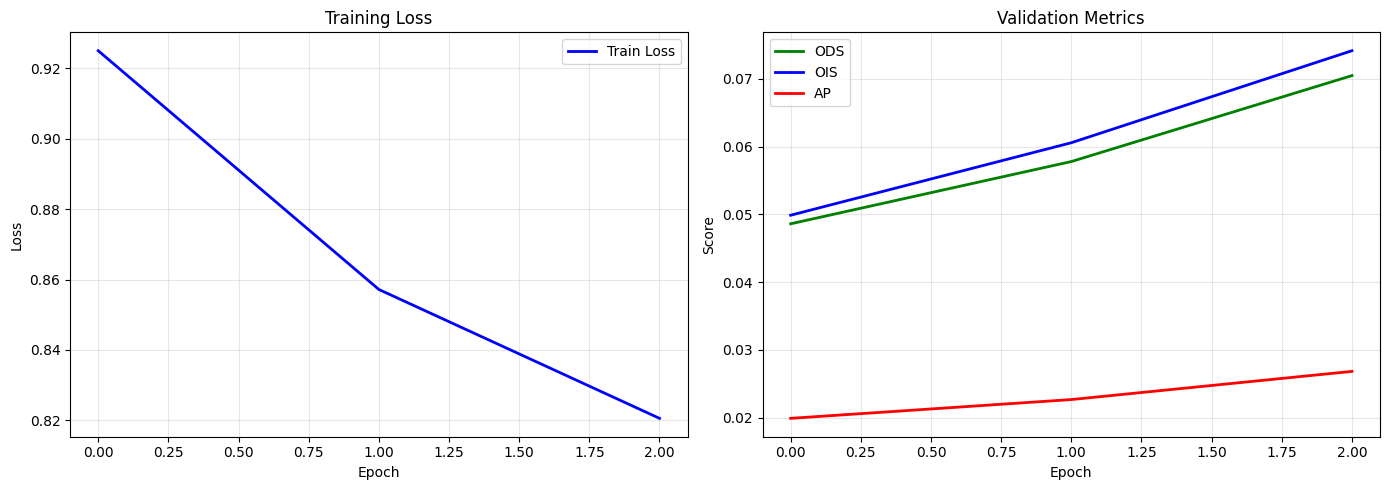

In [14]:
# Cell 7: Plot Training History

fig, axes = plt.subplots(1, 2, figsize=(14, 5))

# Loss
axes[0].plot(history['train_loss'], 'b-', linewidth=2, label='Train Loss')
axes[0].set_xlabel('Epoch')
axes[0].set_ylabel('Loss')
axes[0].set_title('Training Loss')
axes[0].legend()
axes[0].grid(True, alpha=0.3)

# Metrics
axes[1].plot(history['val_ods'], 'g-', linewidth=2, label='ODS')
axes[1].plot(history['val_ois'], 'b-', linewidth=2, label='OIS')
axes[1].plot(history['val_ap'], 'r-', linewidth=2, label='AP')
axes[1].set_xlabel('Epoch')
axes[1].set_ylabel('Score')
axes[1].set_title('Validation Metrics')
axes[1].legend()
axes[1].grid(True, alpha=0.3)

plt.tight_layout()
plt.savefig(str(ARTIFACTS_DIR / 'training_history.png'), dpi=150)
plt.show()

In [15]:
# Cell 8: Final Test Evaluation

IMAGENET_MEAN = torch.tensor([0.485, 0.456, 0.406]).view(3, 1, 1)
IMAGENET_STD = torch.tensor([0.229, 0.224, 0.225]).view(3, 1, 1)

def _denorm_to_uint8(img_chw: torch.Tensor) -> np.ndarray:
    x = img_chw.detach().cpu()
    x = x * IMAGENET_STD + IMAGENET_MEAN
    x = x.clamp(0.0, 1.0)
    x = (x.permute(1, 2, 0).numpy() * 255.0).round().astype(np.uint8)
    return x

def _save_gray01_png(path: Path, arr01: np.ndarray):
    path.parent.mkdir(parents=True, exist_ok=True)
    a = np.clip(arr01, 0.0, 1.0)
    cv2.imwrite(str(path), (a * 255.0).round().astype(np.uint8))

@torch.no_grad()
def export_prediction_triplets(model, loader, out_dir: Path, *, max_images: int = 100, save_input: bool = True, save_gt: bool = True):
    out_dir = Path(out_dir)
    pred_dir = out_dir / 'pred'
    inp_dir = out_dir / 'input'
    gt_dir = out_dir / 'gt'
    pred_dir.mkdir(parents=True, exist_ok=True)
    if save_input:
        inp_dir.mkdir(parents=True, exist_ok=True)
    if save_gt:
        gt_dir.mkdir(parents=True, exist_ok=True)

    manifest = []
    exported = 0
    model.eval()
    for batch in loader:
        images = batch['images'].to(device)
        labels = batch.get('labels', None)
        filenames = batch.get('filename', ['unknown'] * images.shape[0])
        outputs = model(images)
        for i in range(outputs.shape[0]):
            if exported >= max_images:
                df = pd.DataFrame(manifest)
                df.to_csv(out_dir / 'manifest.csv', index=False)
                return df
            name = str(filenames[i])
            safe = ''.join([c if c.isalnum() or c in ('-', '_') else '_' for c in name])
            pred = outputs[i, 0].detach().cpu().numpy().astype(np.float32)
            _save_gray01_png(pred_dir / f'{safe}.png', pred)
            if save_gt and labels is not None:
                gt = labels[i, 0].detach().cpu().numpy().astype(np.float32)
                _save_gray01_png(gt_dir / f'{safe}.png', gt)
            if save_input:
                rgb = _denorm_to_uint8(batch['images'][i])
                bgr = cv2.cvtColor(rgb, cv2.COLOR_RGB2BGR)
                cv2.imwrite(str(inp_dir / f'{safe}.png'), bgr)
            manifest.append({"name": name, "pred": f"pred/{safe}.png", "gt": f"gt/{safe}.png" if save_gt and labels is not None else "", "input": f"input/{safe}.png" if save_input else ""})
            exported += 1
    df = pd.DataFrame(manifest)
    df.to_csv(out_dir / 'manifest.csv', index=False)
    return df

# Load best model (prefer current run output; fallback to legacy models/)
best_path_run = CHECKPOINT_DIR / 'best_xyw_net.pth'
best_path_legacy = Path('./models/best_xyw_net.pth')
best_path = best_path_run if best_path_run.exists() else best_path_legacy
model.load_state_dict(torch.load(str(best_path), map_location=device))
print(f"Loaded best model weights from: {best_path}\n")

# Always compute proxy metrics (fast)
print("Evaluating on TEST set (proxy pixelwise; not paper-comparable)...")
test_ods, test_ois, test_ap = evaluate(model, test_loader, device)

print("\n" + "="*60)
print("FINAL TEST RESULTS (PROXY PIXELWISE)")
print("="*60)
print(f"  proxy ODS (Optimal Dataset Scale): {test_ods:.4f}")
print(f"  proxy OIS (Optimal Image Scale):   {test_ois:.4f}")
print(f"  proxy AP (Average Precision):      {test_ap:.4f}")
print("="*60)

# Save metrics
(RUN_DIR / 'test_metrics_proxy.json').write_text(json.dumps({"proxyODS": float(test_ods), "proxyOIS": float(test_ois), "proxyAP": float(test_ap)}, indent=2), encoding='utf-8')

# Export test predictions (subset)
if EXPORT_TEST_PREDICTIONS:
    export_prediction_triplets(
        model,
        test_loader,
        PREDICTIONS_DIR / 'test',
        max_images=int(PRED_EXPORT_MAX_IMAGES),
        save_input=True,
        save_gt=True,
    )
    print(f"Exported test predictions to: {PREDICTIONS_DIR / 'test'}")

# Optional: paper-standard boundary benchmark via pdollar/edges
eval_protocol = os.environ.get("EDGE_EVAL_PROTOCOL", "pixel").strip().lower()
if eval_protocol == 'bsds':
    print("\nRunning pdollar/edges BSDS boundary benchmark on TEST set...")
    try:
        bsds = evaluate_pdollar_edges(model, test_loader, device, out_root=str(RUN_DIR / 'pdollar_eval'), run_name="test")
        (RUN_DIR / 'test_metrics_pdollar_edges.json').write_text(json.dumps(bsds, indent=2), encoding='utf-8')
        print("\n" + "="*60)
        print("FINAL TEST RESULTS (PDOLLAR/EDGES BSDS)")
        print("="*60)
        print(f"  ODS: {float(bsds.get('ODS', float('nan'))):.4f}")
        print(f"  OIS: {float(bsds.get('OIS', float('nan'))):.4f}")
        print(f"  AP:  {float(bsds.get('AP', float('nan'))):.4f}")
        print("="*60)
    except Exception as e:
        print(f"! BSDS eval requested but failed: {e}")

C:\Users\imed\AppData\Local\Temp\ipykernel_15992\1866488952.py:64: FutureWarning: You are using `torch.load` with `weights_only=False` (the current default value), which uses the default pickle module implicitly. It is possible to construct malicious pickle data which will execute arbitrary code during unpickling (See https://github.com/pytorch/pytorch/blob/main/SECURITY.md#untrusted-models for more details). In a future release, the default value for `weights_only` will be flipped to `True`. This limits the functions that could be executed during unpickling. Arbitrary objects will no longer be allowed to be loaded via this mode unless they are explicitly allowlisted by the user via `torch.serialization.add_safe_globals`. We recommend you start setting `weights_only=True` for any use case where you don't have full control of the loaded file. Please open an issue on GitHub for any issues related to this experimental feature.
  model.load_state_dict(torch.load(str(best_path), map_locatio

Loaded best model weights from: runs\xywnet_20251225_212001\checkpoints\best_xyw_net.pth

Evaluating on TEST set (proxy pixelwise; not paper-comparable)...


Evaluating (proxy pixelwise): 100%|██████████| 13/13 [00:02<00:00,  5.21it/s]



FINAL TEST RESULTS (PROXY PIXELWISE)
  proxy ODS (Optimal Dataset Scale): 0.0909
  proxy OIS (Optimal Image Scale):   0.0930
  proxy AP (Average Precision):      0.0353
Exported test predictions to: runs\xywnet_20251225_212001\predictions\test


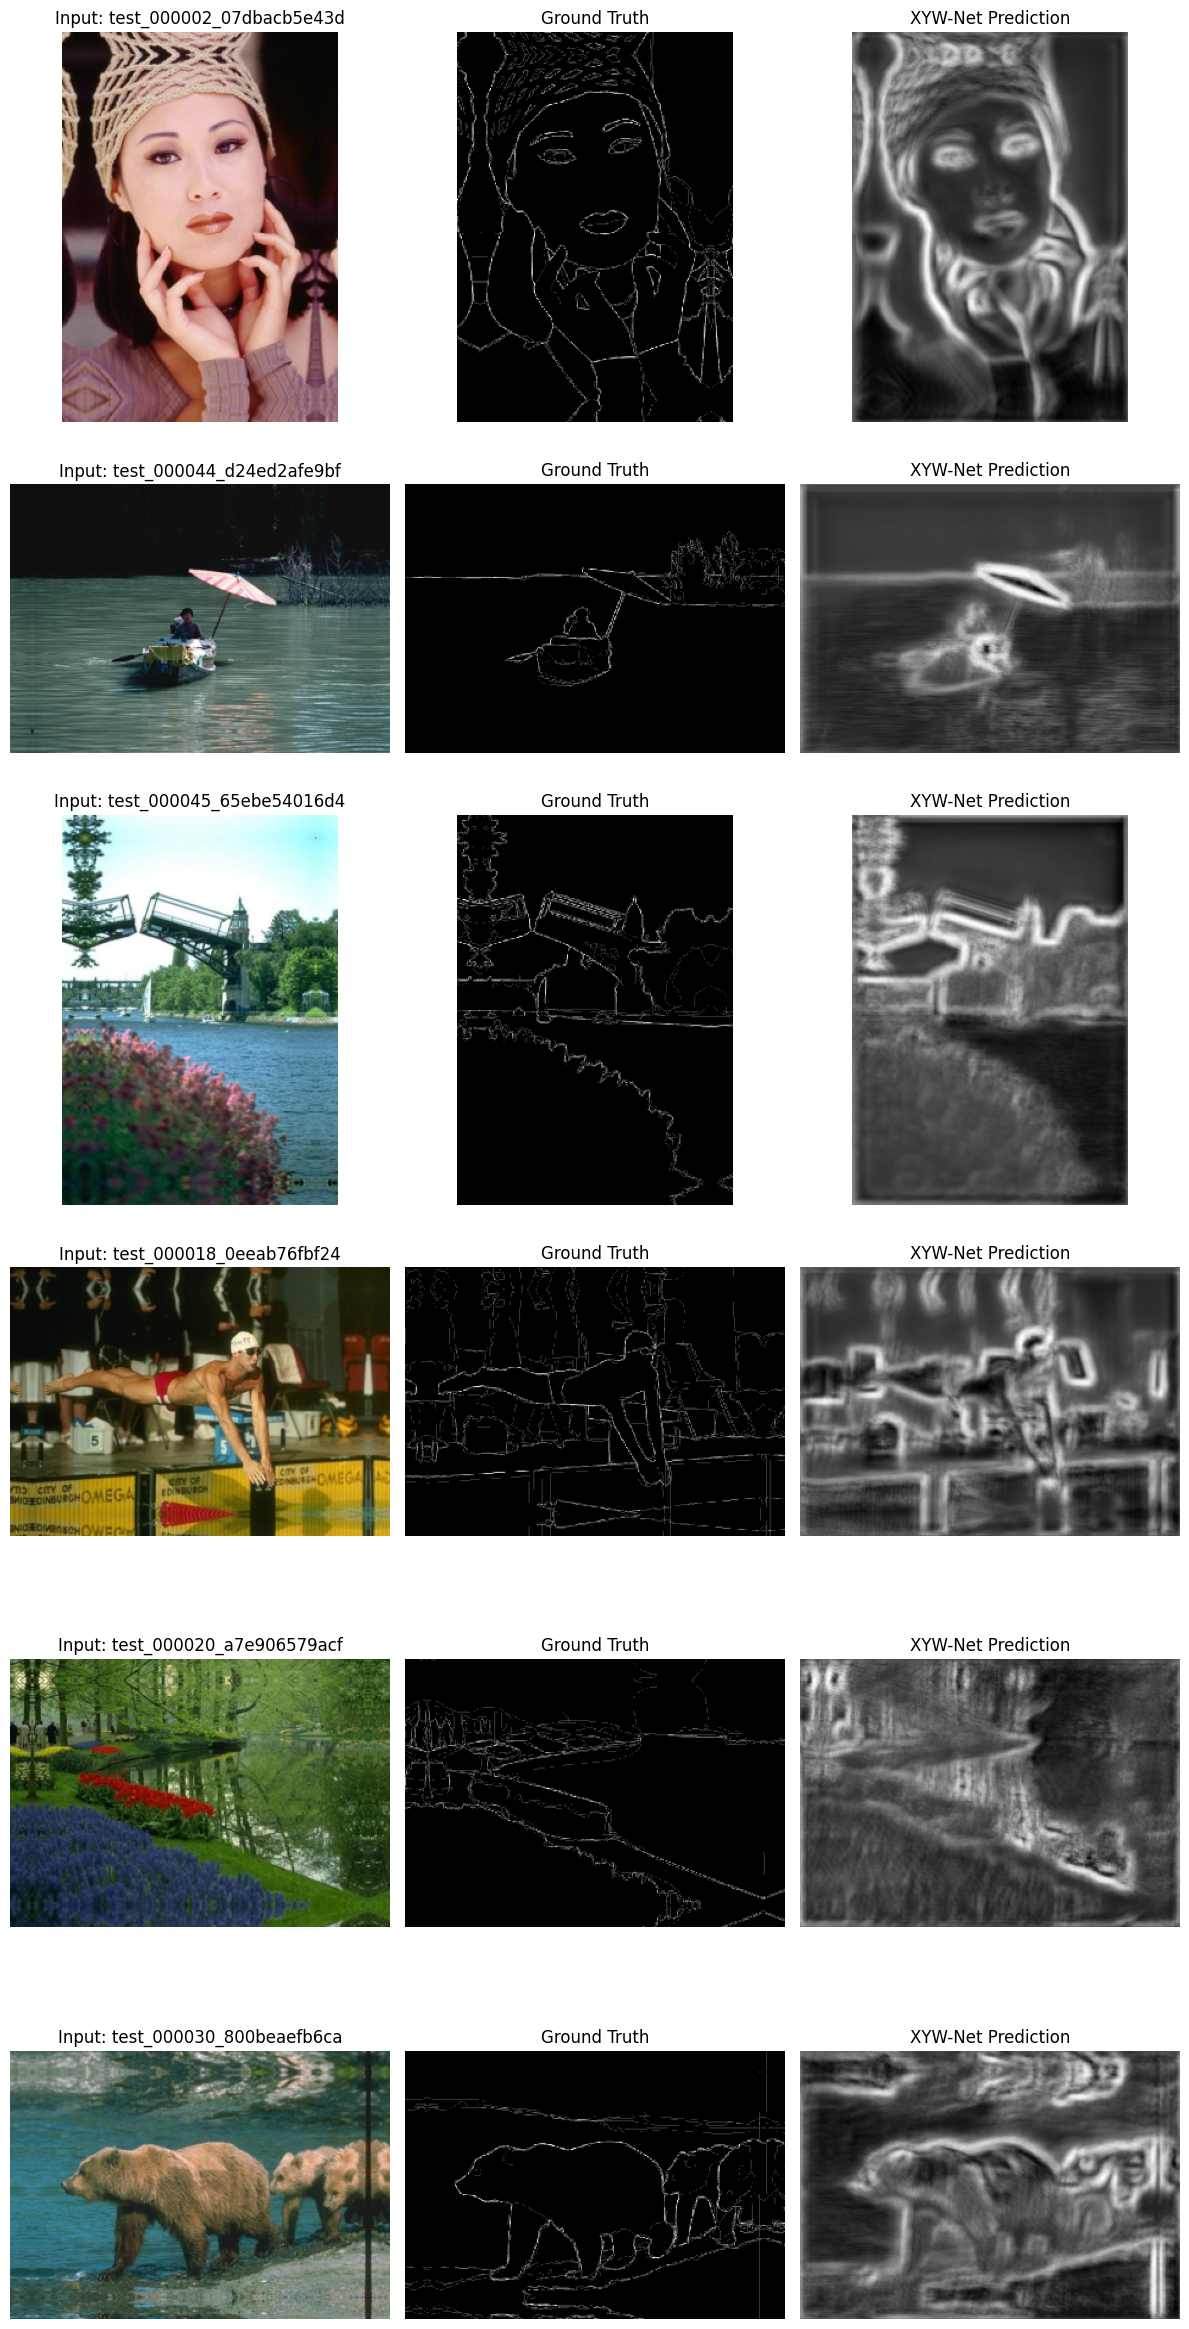

In [16]:
# Cell 9: Visualize Edge Predictions

@torch.no_grad()
def visualize_predictions(model, dataset, device, num_samples=6):
    """Visualize predictions on random samples"""
    model.eval()
    
    mean = torch.tensor([0.485, 0.456, 0.406]).view(3, 1, 1)
    std = torch.tensor([0.229, 0.224, 0.225]).view(3, 1, 1)
    
    indices = np.random.choice(len(dataset), min(num_samples, len(dataset)), replace=False)
    
    fig, axes = plt.subplots(num_samples, 3, figsize=(12, 4*num_samples))
    if num_samples == 1:
        axes = axes.reshape(1, -1)
    
    for i, idx in enumerate(indices):
        sample = dataset[idx]
        img = sample['images'].unsqueeze(0).to(device)
        label = sample['labels'][0].numpy()
        pred = model(img)[0, 0].cpu().numpy()
        
        # Denormalize for viewing
        img_vis = (sample['images'].cpu() * std + mean).clamp(0, 1)
        axes[i, 0].imshow(img_vis.permute(1, 2, 0).numpy())
        axes[i, 0].set_title(f'Input: {sample["filename"]}')
        axes[i, 0].axis('off')
        
        axes[i, 1].imshow(label, cmap='gray')
        axes[i, 1].set_title('Ground Truth')
        axes[i, 1].axis('off')
        
        axes[i, 2].imshow(pred, cmap='gray')
        axes[i, 2].set_title('XYW-Net Prediction')
        axes[i, 2].axis('off')
    
    plt.tight_layout()
    plt.savefig(str(ARTIFACTS_DIR / 'predictions_samples.png'), dpi=150)
    plt.show()

visualize_predictions(model, test_dataset, device, num_samples=6)

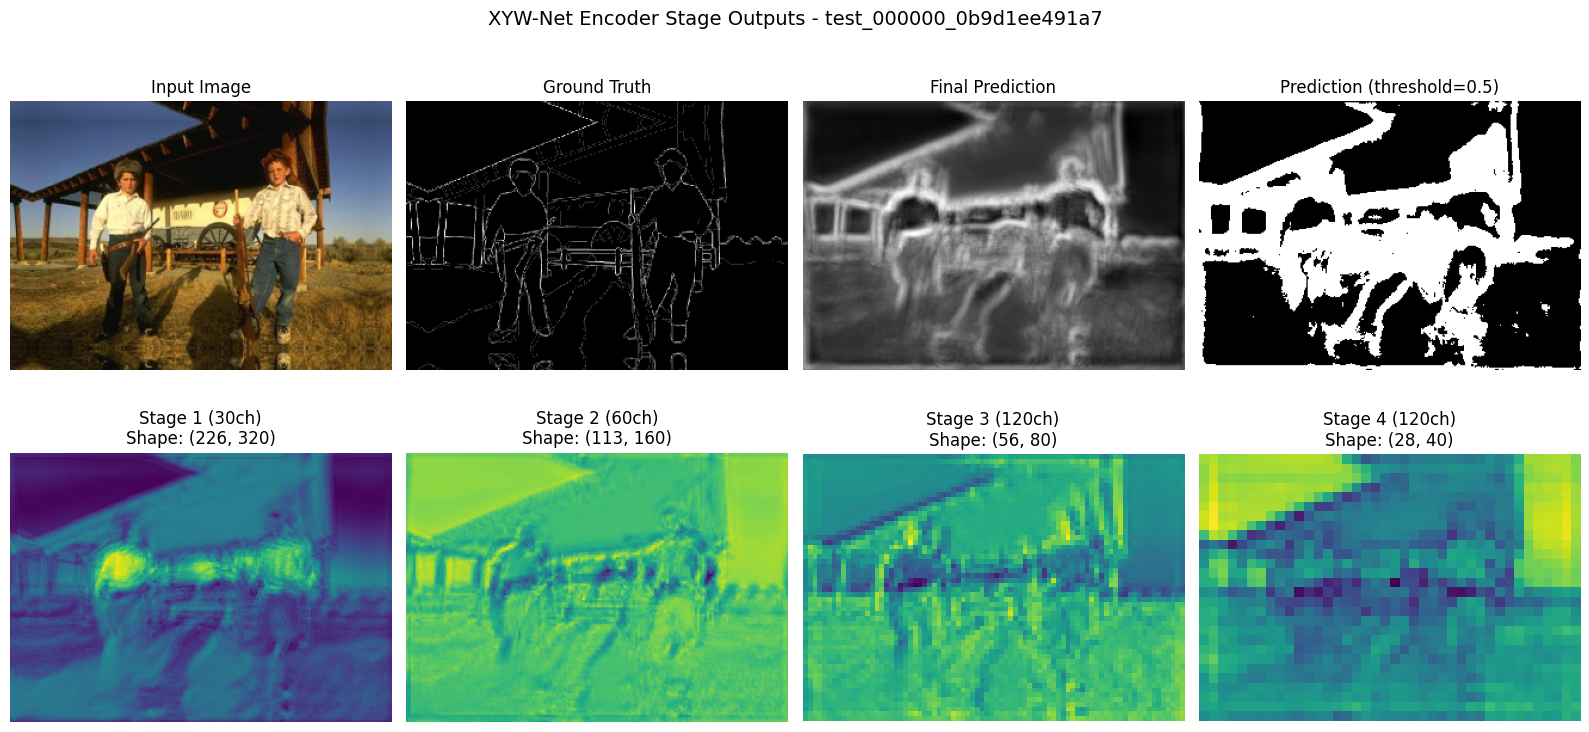

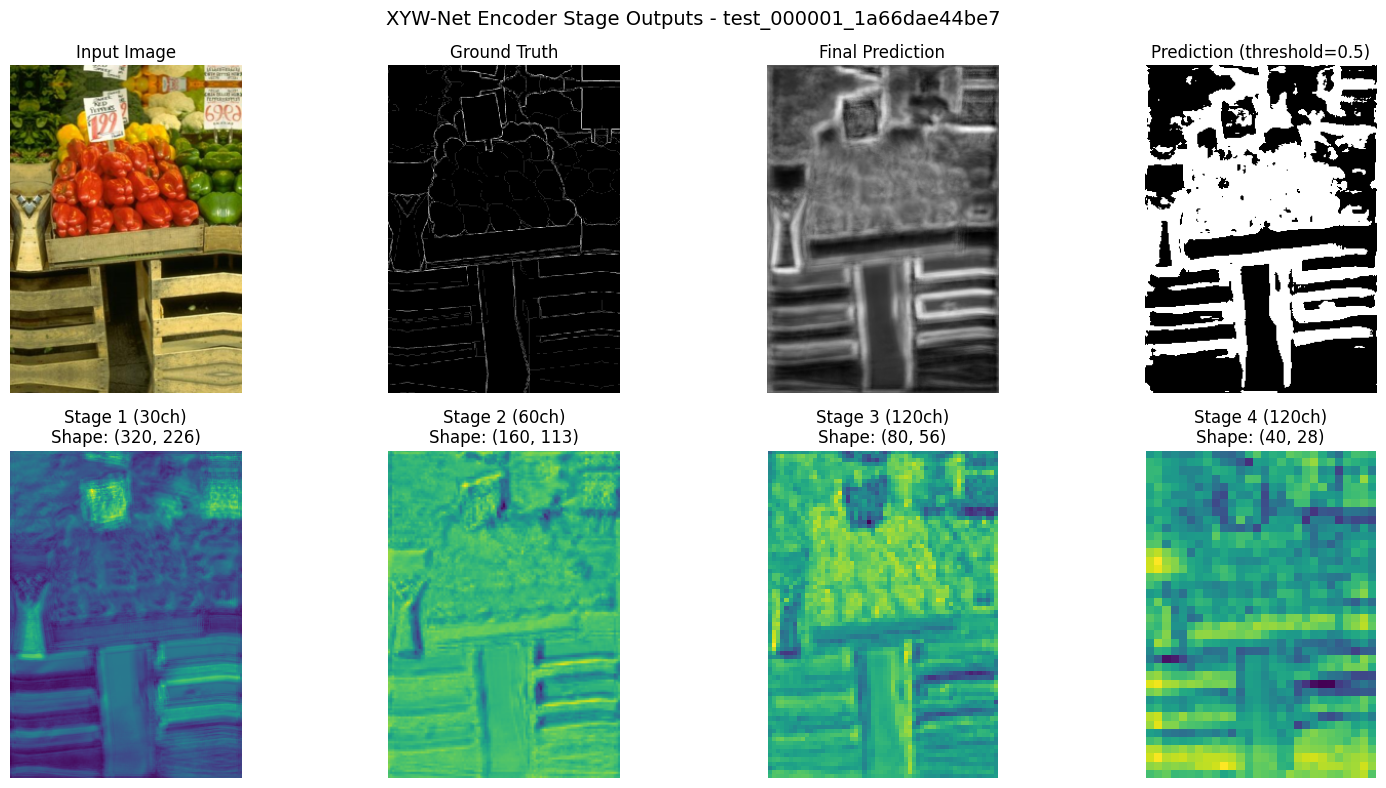

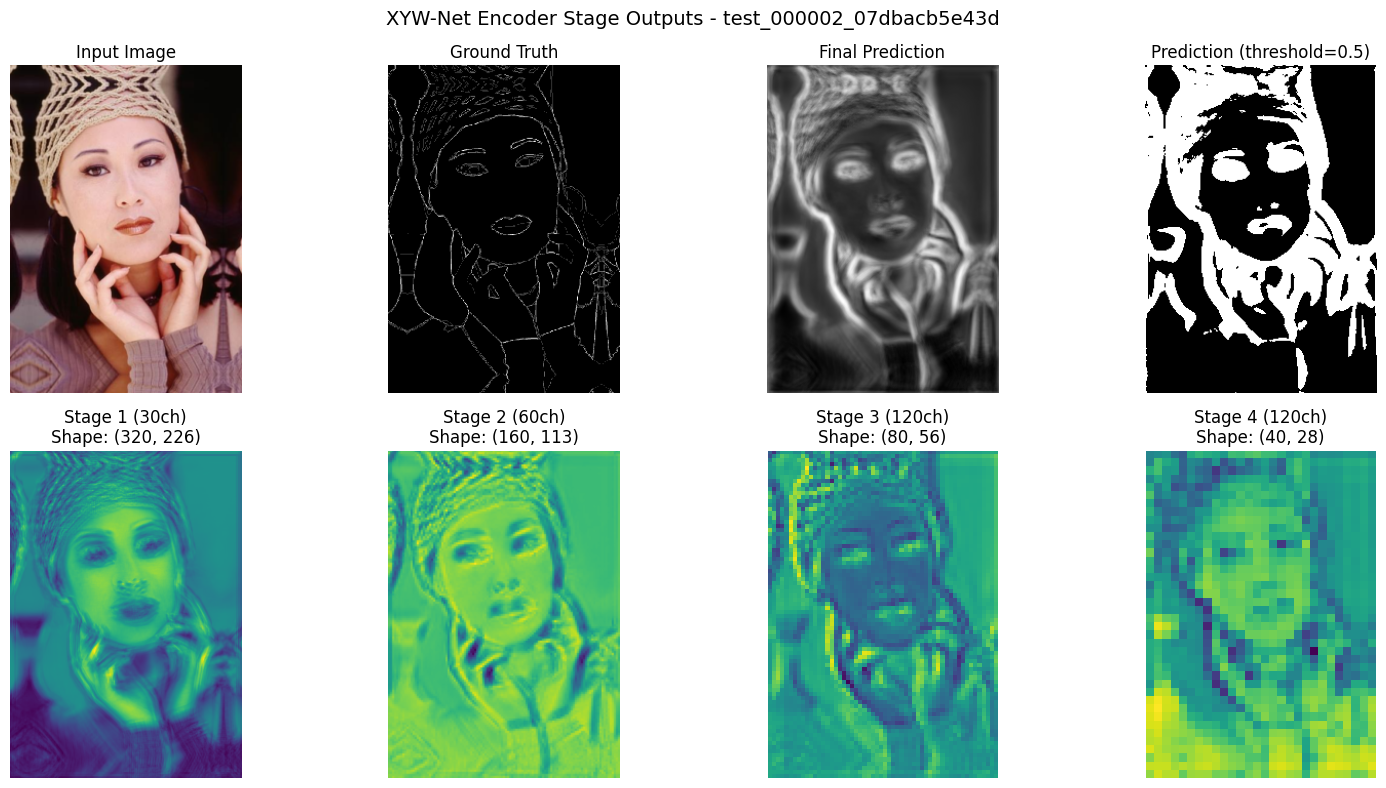

In [17]:
# Cell 10: Visualize Encoder Stage Outputs

@torch.no_grad()
def visualize_stages(model, dataset, device, sample_idx=0):
    """Visualize feature maps at each encoder stage"""
    model.eval()
    
    mean = torch.tensor([0.485, 0.456, 0.406]).view(3, 1, 1)
    std = torch.tensor([0.229, 0.224, 0.225]).view(3, 1, 1)
    
    sample = dataset[sample_idx]
    img = sample['images'].unsqueeze(0).to(device)
    
    # Get stage outputs
    final, (s1, s2, s3, s4) = model.forward_with_stages(img)
    
    fig, axes = plt.subplots(2, 4, figsize=(16, 8))
    
    # Original image (denormalized)
    img_vis = (sample['images'].cpu() * std + mean).clamp(0, 1)
    axes[0, 0].imshow(img_vis.permute(1, 2, 0).numpy())
    axes[0, 0].set_title('Input Image')
    axes[0, 0].axis('off')
    
    # Ground truth
    axes[0, 1].imshow(sample['labels'][0].numpy(), cmap='gray')
    axes[0, 1].set_title('Ground Truth')
    axes[0, 1].axis('off')
    
    # Final prediction
    axes[0, 2].imshow(final[0, 0].cpu().numpy(), cmap='gray')
    axes[0, 2].set_title('Final Prediction')
    axes[0, 2].axis('off')
    
    # Thresholded prediction
    pred_binary = (final[0, 0].cpu().numpy() > 0.5).astype(float)
    axes[0, 3].imshow(pred_binary, cmap='gray')
    axes[0, 3].set_title('Prediction (threshold=0.5)')
    axes[0, 3].axis('off')
    
    # Stage feature maps (mean across channels)
    stages = [s1, s2, s3, s4]
    stage_names = ['Stage 1 (30ch)', 'Stage 2 (60ch)', 'Stage 3 (120ch)', 'Stage 4 (120ch)']
    
    for i, (stage, name) in enumerate(zip(stages, stage_names)):
        feat_mean = stage[0].mean(dim=0).cpu().numpy()
        feat_norm = (feat_mean - feat_mean.min()) / (feat_mean.max() - feat_mean.min() + 1e-8)
        axes[1, i].imshow(feat_norm, cmap='viridis')
        axes[1, i].set_title(f'{name}\nShape: {tuple(stage.shape[2:])}')
        axes[1, i].axis('off')
    
    plt.suptitle(f'XYW-Net Encoder Stage Outputs - {sample["filename"]}', fontsize=14)
    plt.tight_layout()
    plt.savefig(str(ARTIFACTS_DIR / f"stage_outputs_{sample['filename']}.png"), dpi=150)
    plt.show()

# Visualize for a few samples
for idx in [0, 1, 2]:
    if idx < len(test_dataset):
        visualize_stages(model, test_dataset, device, sample_idx=idx)

In [ ]:
# Cell 12: Visualize *all key components* (XYW blocks + decoder) and SAVE to disk
# This helps explain what each component is doing (important for ablation/report).

import json
import re
from pathlib import Path

import numpy as np
import torch
import matplotlib.pyplot as plt

# -------------------------------
# Config
# -------------------------------
VIZ_COMPONENTS_OUT = ARTIFACTS_DIR / "component_viz"
VIZ_COMPONENTS_OUT.mkdir(parents=True, exist_ok=True)

VIZ_SAMPLE_INDICES = [0, 1, 2]  # change as needed
VIZ_MAX_CHANNELS = 3            # saves first N channel maps per tensor (keeps disk reasonable)
VIZ_SAVE_OVERLAY = True         # overlay activations on input
VIZ_CMAP = "viridis"

# If you want fewer/more modules, edit these tokens.
HOOK_NAME_TOKENS = [
    # encoder stages + XYW blocks
    "encode.s1_", "encode.s2_", "encode.s3_", "encode.s4_",
    "xyw1_", "xyw2_", "xyw3_", "xyw4_",
    "Xcenter", "Ycenter", "Xsurround", "Ysurround", "w.",

    # decoder pyramid + heads
    "decode.f43", "decode.f32", "decode.f21", "decode.f", "decode.elc",
]

# -------------------------------
# Helpers
# -------------------------------
_mean = torch.tensor([0.485, 0.456, 0.406]).view(3, 1, 1)
_std = torch.tensor([0.229, 0.224, 0.225]).view(3, 1, 1)


def _denorm_img(img_chw: torch.Tensor) -> np.ndarray:
    # img_chw: (3,H,W), normalized
    img = (img_chw.cpu() * _std + _mean).clamp(0, 1)
    img_hwc = img.permute(1, 2, 0).numpy()
    return img_hwc


def _norm_01(x: np.ndarray) -> np.ndarray:
    x = x.astype(np.float32)
    mn = float(np.min(x))
    mx = float(np.max(x))
    return (x - mn) / (mx - mn + 1e-8)


def _safe_name(s: str) -> str:
    s = s.replace("/", "_").replace("\\", "_")
    s = s.replace(".", "__").replace(":", "_")
    s = re.sub(r"[^a-zA-Z0-9_\-]+", "_", s)
    return s[:180]


def _save_map_png(path: Path, arr2d: np.ndarray, cmap: str = VIZ_CMAP) -> None:
    path.parent.mkdir(parents=True, exist_ok=True)
    plt.figure(figsize=(5, 5))
    plt.imshow(arr2d, cmap=cmap)
    plt.axis("off")
    plt.tight_layout(pad=0)
    plt.savefig(str(path), dpi=160, bbox_inches="tight", pad_inches=0)
    plt.close()


def _save_overlay_png(path: Path, img_hwc: np.ndarray, heat2d: np.ndarray, alpha: float = 0.45) -> None:
    path.parent.mkdir(parents=True, exist_ok=True)
    plt.figure(figsize=(6, 6))
    plt.imshow(img_hwc)
    plt.imshow(heat2d, cmap=VIZ_CMAP, alpha=alpha)
    plt.axis("off")
    plt.tight_layout(pad=0)
    plt.savefig(str(path), dpi=160, bbox_inches="tight", pad_inches=0)
    plt.close()


def _flatten_output(out):
    # returns list[(suffix, tensor)]
    if torch.is_tensor(out):
        return [("", out)]
    if isinstance(out, (list, tuple)):
        flat = []
        for i, v in enumerate(out):
            if torch.is_tensor(v):
                flat.append((f":{i}", v))
        return flat
    return []


def _select_hook_modules(model: torch.nn.Module):
    selected = []
    for name, module in model.named_modules():
        if not name:
            continue
        if any(tok in name for tok in HOOK_NAME_TOKENS):
            selected.append((name, module))
    # Remove very deep duplicates by preferring shorter names first
    selected.sort(key=lambda x: (len(x[0]), x[0]))
    return selected


@torch.no_grad()
def capture_and_save_components(model, dataset, device, sample_idx: int):
    model.eval()

    sample = dataset[sample_idx]
    img = sample["images"].unsqueeze(0).to(device)
    img_hwc = _denorm_img(sample["images"])
    gt = sample["labels"][0].cpu().numpy().astype(np.float32)

    sample_dir = VIZ_COMPONENTS_OUT / f"sample_{sample_idx:04d}_{_safe_name(str(sample.get('filename', 'unknown')))}"
    sample_dir.mkdir(parents=True, exist_ok=True)

    # Save input/gt
    _save_map_png(sample_dir / "gt.png", _norm_01(gt), cmap="gray")
    plt.figure(figsize=(6, 6))
    plt.imshow(img_hwc)
    plt.axis("off")
    plt.tight_layout(pad=0)
    plt.savefig(str(sample_dir / "input.png"), dpi=160, bbox_inches="tight", pad_inches=0)
    plt.close()

    captured = {}
    handles = []

    def hook_fn(name):
        def _hook(_m, _inp, out):
            for suf, t in _flatten_output(out):
                key = f"{name}{suf}"
                if torch.is_tensor(t):
                    captured[key] = t.detach().cpu()
        return _hook

    # Register hooks
    for name, module in _select_hook_modules(model):
        handles.append(module.register_forward_hook(hook_fn(name)))

    # Forward pass
    pred = model(img)  # (B,1,H,W)

    # Remove hooks
    for h in handles:
        try:
            h.remove()
        except Exception:
            pass

    # Save prediction
    pred2d = pred[0, 0].detach().cpu().numpy().astype(np.float32)
    _save_map_png(sample_dir / "pred.png", _norm_01(pred2d), cmap="gray")
    if VIZ_SAVE_OVERLAY:
        _save_overlay_png(sample_dir / "pred_overlay.png", img_hwc, _norm_01(pred2d))

    manifest = {
        "sample_idx": int(sample_idx),
        "filename": str(sample.get("filename", "unknown")),
        "saved_dir": str(sample_dir),
        "modules": {},
    }

    # For each captured tensor: save mean/max + a few channels
    for key, t in captured.items():
        if not torch.is_tensor(t):
            continue

        # Expect (B,C,H,W) or (B,1,H,W) mostly
        shape = tuple(t.shape)
        if t.ndim == 4:
            x = t[0]
            # x: (C,H,W)
            mean_map = x.mean(dim=0).numpy()
            max_map = x.max(dim=0).values.numpy()

            base = _safe_name(key)
            files = []

            mean_n = _norm_01(mean_map)
            max_n = _norm_01(max_map)

            mean_path = sample_dir / "activations" / f"{base}__mean.png"
            max_path = sample_dir / "activations" / f"{base}__max.png"
            _save_map_png(mean_path, mean_n)
            _save_map_png(max_path, max_n)
            files += [str(mean_path), str(max_path)]

            if VIZ_SAVE_OVERLAY:
                ov_path = sample_dir / "overlays" / f"{base}__mean_overlay.png"
                _save_overlay_png(ov_path, img_hwc, mean_n)
                files.append(str(ov_path))

            # first N channels (often enough to see what it learns)
            c = int(x.shape[0])
            for ci in range(min(VIZ_MAX_CHANNELS, c)):
                ch_map = _norm_01(x[ci].numpy())
                ch_path = sample_dir / "channels" / f"{base}__ch{ci:03d}.png"
                _save_map_png(ch_path, ch_map)
                files.append(str(ch_path))

            manifest["modules"][key] = {
                "shape": shape,
                "dtype": str(t.dtype),
                "min": float(t.min().item()),
                "max": float(t.max().item()),
                "saved": files,
            }

        elif t.ndim == 3:
            # (B,H,W)
            x = t[0].numpy()
            base = _safe_name(key)
            p = sample_dir / "activations" / f"{base}.png"
            _save_map_png(p, _norm_01(x))
            manifest["modules"][key] = {"shape": shape, "dtype": str(t.dtype), "saved": [str(p)]}

        else:
            # Skip scalars/vectors
            manifest["modules"][key] = {"shape": shape, "dtype": str(t.dtype), "saved": []}

    (sample_dir / "manifest.json").write_text(json.dumps(manifest, indent=2), encoding="utf-8")
    print(f"✓ Saved component visualizations for sample {sample_idx} -> {sample_dir}")


# -------------------------------
# Run it
# -------------------------------
for idx in VIZ_SAMPLE_INDICES:
    if 0 <= idx < len(test_dataset):
        capture_and_save_components(model, test_dataset, device, sample_idx=idx)

# Optional: make a single zip for easy sharing / backup
try:
    import shutil
    zip_base = str(ARTIFACTS_DIR / "component_viz")
    zip_path = shutil.make_archive(zip_base, "zip", root_dir=str(VIZ_COMPONENTS_OUT))
    print(f"✓ Zipped: {zip_path}")

    # If training cell defined backup helpers, back up the zip too
    _b_local = globals().get("_backup_to_local", None)
    _b_s3 = globals().get("_backup_to_s3", None)
    if callable(_b_local):
        _b_local(Path(zip_path), "artifacts/component_viz.zip")
    if callable(_b_s3):
        _b_s3(Path(zip_path), "artifacts/component_viz.zip")
except Exception as e:
    print(f"(zip/backup skipped): {e}")

Computing PR curve: 100%|██████████| 13/13 [00:02<00:00,  6.17it/s]


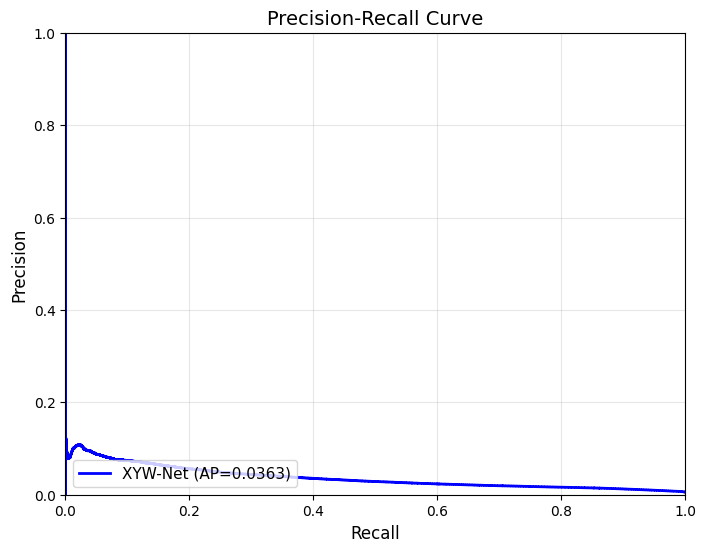

Average Precision: 0.0363


In [18]:
# Cell 11: Precision-Recall Curve

@torch.no_grad()
def plot_pr_curve(model, loader, device):
    """Plot precision-recall curve"""
    model.eval()
    all_preds = []
    all_labels = []
    
    for batch in tqdm(loader, desc='Computing PR curve'):
        images = batch['images'].to(device)
        labels = batch['labels']
        outputs = model(images)
        
        for i in range(outputs.shape[0]):
            all_preds.append(outputs[i, 0].cpu().numpy().flatten())
            all_labels.append((labels[i, 0].numpy().flatten() > 0.5).astype(int))
    
    all_preds = np.concatenate(all_preds)
    all_labels = np.concatenate(all_labels)
    
    precision, recall, thresholds = precision_recall_curve(all_labels, all_preds)
    ap = average_precision_score(all_labels, all_preds)
    
    plt.figure(figsize=(8, 6))
    plt.plot(recall, precision, 'b-', linewidth=2, label=f'XYW-Net (AP={ap:.4f})')
    plt.xlabel('Recall', fontsize=12)
    plt.ylabel('Precision', fontsize=12)
    plt.title('Precision-Recall Curve', fontsize=14)
    plt.legend(loc='lower left', fontsize=11)
    plt.grid(True, alpha=0.3)
    plt.xlim([0, 1])
    plt.ylim([0, 1])
    plt.savefig(str(ARTIFACTS_DIR / 'pr_curve.png'), dpi=150)
    plt.show()
    
    return ap

ap = plot_pr_curve(model, test_loader, device)
print(f"Average Precision: {ap:.4f}")

In [19]:
# Cell 12: Summary Results Table

print("\n" + "="*70)
print("                    XYW-NET EVALUATION SUMMARY")
print("="*70)
print(f"")
print(f"  Dataset:          {DATA_ROOT}")
print(f"  Train samples:    {len(train_dataset)}")
print(f"  Val samples:      {len(val_dataset)}")
print(f"  Test samples:     {len(test_dataset)}")
print(f"")
print(f"  Training epochs:  {NUM_EPOCHS}")
print(f"  Learning rate:    {LEARNING_RATE}")
print(f"  Batch size:       {BATCH_SIZE}")
print(f"")
print("  " + "-"*50)
print(f"  TEST SET METRICS:")
print("  " + "-"*50)
print(f"  proxy ODS:   {test_ods:.4f}")
print(f"  proxy OIS:   {test_ois:.4f}")
print(f"  proxy AP:    {test_ap:.4f}")
print("="*70)
print(f"")
print("Saved run folder:")
print(f"  - {RUN_DIR}")
print("Key outputs:")
print(f"  - {CHECKPOINT_DIR / 'best_xyw_net.pth'}")
print(f"  - {CHECKPOINT_DIR / 'xywnet_full_checkpoint.pth'}")
print(f"  - {ARTIFACTS_DIR / 'xywnet_model.pt'}")
print(f"  - {ARTIFACTS_DIR / 'training_history.png'}")
print(f"  - {ARTIFACTS_DIR / 'predictions_samples.png'}")
print(f"  - {ARTIFACTS_DIR / 'pr_curve.png'}")
print(f"  - {PREDICTIONS_DIR / 'test' / 'manifest.csv'}")


                    XYW-NET EVALUATION SUMMARY

  Dataset:          ./datasets/RCF_small/processed_HED_BSDS_small
  Train samples:    200
  Val samples:      50
  Test samples:     50

  Training epochs:  3
  Learning rate:    0.0001
  Batch size:       4

  --------------------------------------------------
  TEST SET METRICS:
  --------------------------------------------------
  proxy ODS:   0.0909
  proxy OIS:   0.0930
  proxy AP:    0.0353

Saved run folder:
  - runs\xywnet_20251225_212001
Key outputs:
  - runs\xywnet_20251225_212001\checkpoints\best_xyw_net.pth
  - runs\xywnet_20251225_212001\checkpoints\xywnet_full_checkpoint.pth
  - runs\xywnet_20251225_212001\artifacts\xywnet_model.pt
  - runs\xywnet_20251225_212001\artifacts\training_history.png
  - runs\xywnet_20251225_212001\artifacts\predictions_samples.png
  - runs\xywnet_20251225_212001\artifacts\pr_curve.png
  - runs\xywnet_20251225_212001\predictions\test\manifest.csv
